<a href="https://colab.research.google.com/github/sellyrk/Analisis-Segmentasi-Faktor-Perceraian-berdasarkan-Provinsi-di-Indonesia-Tahun-2024/blob/main/MKR_ML_Data_Cerai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Data

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Data Faktor Cerai.csv")
df

,Provinsi,Fakor Perceraian - Zina,Fakor Perceraian - Mabuk,Fakor Perceraian - Madat,Fakor Perceraian - Judi,Fakor Perceraian - Meninggalkan Salah satu Pihak,Fakor Perceraian - Dihukum Penjara,Fakor Perceraian - Poligami,Fakor Perceraian - Kekerasan Dalam Rumah Tangga,Fakor Perceraian - Cacat Badan,Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus,Fakor Perceraian - Kawin Paksa,Fakor Perceraian - Murtad,Fakor Perceraian - Ekonomi,Fakor Perceraian - Jumlah
0,Aceh,6,10,18,26,551,61,28,122,16,5035,3,9,218,6103
1,Sumatera Utara,4,8,23,58,830,62,23,117,4,14454,NaN,73,299,15955
2,Sumatera Barat,2,7,5,30,936,29,22,100,6,6922,NaN,9,224,8292
3,Riau,5,12,25,36,745,99,12,125,7,6922,5,18,231,8242
4,Jambi,4,20,30,46,375,34,9,77,1,3746,2,6,230,4580
5,Sumatera Selatan,19,38,35,120,769,83,35,427,7,7851,NaN,18,778,10180
6,Bengkulu,2,8,4,26,263,18,6,85,1,2991,NaN,5,130,3539
7,Lampung,8,72,9,131,655,31,29,259,6,11195,NaN,40,2168,14603
8,Kepulauan Bangka Belitung,2,39,NaN,65,163,18,3,123,3,1601,NaN,6,268,2291
9,Kepulauan Riau,10,14,6,22,311,23,3,93,2,2749,NaN,4,148,3385


# Data Pre-Processing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 15 columns):
 #   Column                                                          Non-Null Count  Dtype 
---  ------                                                          --------------  ----- 
 0   Provinsi                                                        39 non-null     object
 1   Fakor Perceraian - Zina                                         37 non-null     object
 2   Fakor Perceraian - Mabuk                                        38 non-null     object
 3   Fakor Perceraian - Madat                                        29 non-null     object
 4   Fakor Perceraian - Judi                                         39 non-null     object
 5   Fakor Perceraian - Meninggalkan Salah satu Pihak                39 non-null     object
 6   Fakor Perceraian - Dihukum Penjara                              39 non-null     object
 7   Fakor Perceraian - Poligami                                     

In [ ]:
df = df[~df['Provinsi'].isin(['Indonesia'])]

## Handle Missing Values

In [ ]:
df.isna().sum()

,0
Provinsi,0
Fakor Perceraian - Zina,2
Fakor Perceraian - Mabuk,1
Fakor Perceraian - Madat,10
Fakor Perceraian - Judi,0
Fakor Perceraian - Meninggalkan Salah satu Pihak,0
Fakor Perceraian - Dihukum Penjara,0
Fakor Perceraian - Poligami,3
Fakor Perceraian - Kekerasan Dalam Rumah Tangga,0
Fakor Perceraian - Cacat Badan,5


In [ ]:
faktor_cols = [
    "Fakor Perceraian - Zina",
    "Fakor Perceraian - Mabuk",
    "Fakor Perceraian - Madat",
    "Fakor Perceraian - Judi",
    "Fakor Perceraian - Meninggalkan Salah satu Pihak",
    "Fakor Perceraian - Dihukum Penjara",
    "Fakor Perceraian - Poligami",
    "Fakor Perceraian - Kekerasan Dalam Rumah Tangga",
    "Fakor Perceraian - Cacat Badan",
    "Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus",
    "Fakor Perceraian - Kawin Paksa",
    "Fakor Perceraian - Murtad",
    "Fakor Perceraian - Ekonomi"
]


### Mengubah tipe data dulu

In [ ]:
# Pastikan semua numeric
for col in faktor_cols + ["Fakor Perceraian - Jumlah"]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

<ipython-input-6-24712f7f8536>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors='coerce')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 0 to 37
Data columns (total 15 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Provinsi                                                        38 non-null     object 
 1   Fakor Perceraian - Zina                                         32 non-null     float64
 2   Fakor Perceraian - Mabuk                                        33 non-null     float64
 3   Fakor Perceraian - Madat                                        24 non-null     float64
 4   Fakor Perceraian - Judi                                         34 non-null     float64
 5   Fakor Perceraian - Meninggalkan Salah satu Pihak                34 non-null     float64
 6   Fakor Perceraian - Dihukum Penjara                              34 non-null     float64
 7   Fakor Perceraian - Poligami                                 

### Mengisi null dengan penjumlahan faktor

Menggunakan rasio kontribusi faktor terhadap total dari provinsi-provinsi lain yang memiliki data lengkap. Dengan imputasi berdasarkan proporsi rata-rata nasional faktor terhadap total perceraian dan mempertimbangkan provinis

In [ ]:
# 1. Isi 'Jumlah' yang 0 atau NaN dengan penjumlahan faktor
jumlah_kosong = df["Fakor Perceraian - Jumlah"].isna() | (df["Fakor Perceraian - Jumlah"] == 0)
df.loc[jumlah_kosong, "Fakor Perceraian - Jumlah"] = df.loc[jumlah_kosong, faktor_cols].sum(axis=1,
                                                                                            min_count=1)

In [ ]:
jumlah_kosong

,Fakor Perceraian - Jumlah
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


Menghitung rasio rata-arata untuk memperkirakan nilai dari luas besar kecilnya provinsi, yang didapat dari setiap faktor terhadap Jumlah dari provinsi yang valid.

In [ ]:
# 2. Hitung rasio rata-rata setiap faktor terhadap jumlah (hanya untuk baris valid)
avg_ratios = {}
for col in faktor_cols:
    ratio_col = df[col] / df["Fakor Perceraian - Jumlah"]
    avg_ratios[col] = ratio_col[df[col].notna() & df["Fakor Perceraian - Jumlah"].notna()].mean()

In [ ]:
avg_ratios

{'Fakor Perceraian - Zina': np.float64(0.001685098083458953),
 'Fakor Perceraian - Mabuk': np.float64(0.01097513273567427),
 'Fakor Perceraian - Madat': np.float64(0.002056680950157457),
 'Fakor Perceraian - Judi': np.float64(0.007681860955098936),
 'Fakor Perceraian - Meninggalkan Salah satu Pihak': np.float64(0.11596940090625946),
 'Fakor Perceraian - Dihukum Penjara': np.float64(0.005893897848593761),
 'Fakor Perceraian - Poligami': np.float64(0.0028670135768255616),
 'Fakor Perceraian - Kekerasan Dalam Rumah Tangga': np.float64(0.03108751135478641),
 'Fakor Perceraian - Cacat Badan': np.float64(0.0010734291544886045),
 'Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus': np.float64(0.7319073304516965),
 'Fakor Perceraian - Kawin Paksa': np.float64(0.0009377691774683243),
 'Fakor Perceraian - Murtad': np.float64(0.004678680152196063),
 'Fakor Perceraian - Ekonomi': np.float64(0.08492865047270341)}

Imputasi nilai NaN di tiap faktor dengan: rasio × jumlah (jika jumlah > 0). Mengisi (imputasi) nilai NaN di tiap kolom faktor perceraian, berdasarkan rasio rerata nasional dari tiap faktor terhadap total jumlah perceraian.

In [ ]:
# 3. Imputasi nilai kosong pada tiap faktor
for col in faktor_cols:
    missing_idx = df[df[col].isna()].index
    for i in missing_idx:
        jumlah = df.loc[i, "Fakor Perceraian - Jumlah"]
        if pd.notna(jumlah) and jumlah > 0:
            estimasi = avg_ratios[col] * jumlah
            df.loc[i, col] = round(estimasi)

In [ ]:
missing_idx

Index([33, 35, 36, 37], dtype='int64')

In [ ]:
print(df[faktor_cols + ["Fakor Perceraian - Jumlah"]].isna().sum())

Fakor Perceraian - Zina                                           4
Fakor Perceraian - Mabuk                                          4
Fakor Perceraian - Madat                                          4
Fakor Perceraian - Judi                                           4
Fakor Perceraian - Meninggalkan Salah satu Pihak                  4
Fakor Perceraian - Dihukum Penjara                                4
Fakor Perceraian - Poligami                                       4
Fakor Perceraian - Kekerasan Dalam Rumah Tangga                   4
Fakor Perceraian - Cacat Badan                                    4
Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus    4
Fakor Perceraian - Kawin Paksa                                    4
Fakor Perceraian - Murtad                                         4
Fakor Perceraian - Ekonomi                                        4
Fakor Perceraian - Jumlah                                         4
dtype: int64


### Penanganan missing values yg masih tersisa

In [ ]:
df.isna().sum()

,0
Provinsi,0
Fakor Perceraian - Zina,4
Fakor Perceraian - Mabuk,4
Fakor Perceraian - Madat,4
Fakor Perceraian - Judi,4
Fakor Perceraian - Meninggalkan Salah satu Pihak,4
Fakor Perceraian - Dihukum Penjara,4
Fakor Perceraian - Poligami,4
Fakor Perceraian - Kekerasan Dalam Rumah Tangga,4
Fakor Perceraian - Cacat Badan,4


Papua Selatan, Tengah, Pegunungan, dan Papua Barat Daya memang baru dibentuk tahun 2022 dan belum tentu memiliki data terpisah di tahun 2024. Data mereka kemungkinan masih masuk dalam provinsi induk lama, yaitu Papua.

In [ ]:
# Drop baris yang semua faktornya NaN dan jumlahnya juga NaN
rows_all_nan = df[faktor_cols + ["Fakor Perceraian - Jumlah"]].isna().all(axis=1)
clean_df = df[~rows_all_nan]

In [ ]:
clean_df.isna().sum()

,0
Provinsi,0
Fakor Perceraian - Zina,0
Fakor Perceraian - Mabuk,0
Fakor Perceraian - Madat,0
Fakor Perceraian - Judi,0
Fakor Perceraian - Meninggalkan Salah satu Pihak,0
Fakor Perceraian - Dihukum Penjara,0
Fakor Perceraian - Poligami,0
Fakor Perceraian - Kekerasan Dalam Rumah Tangga,0
Fakor Perceraian - Cacat Badan,0


In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, 0 to 34
Data columns (total 15 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Provinsi                                                        34 non-null     object 
 1   Fakor Perceraian - Zina                                         34 non-null     float64
 2   Fakor Perceraian - Mabuk                                        34 non-null     float64
 3   Fakor Perceraian - Madat                                        34 non-null     float64
 4   Fakor Perceraian - Judi                                         34 non-null     float64
 5   Fakor Perceraian - Meninggalkan Salah satu Pihak                34 non-null     float64
 6   Fakor Perceraian - Dihukum Penjara                              34 non-null     float64
 7   Fakor Perceraian - Poligami                                 

In [ ]:
clean_df

,Provinsi,Fakor Perceraian - Zina,Fakor Perceraian - Mabuk,Fakor Perceraian - Madat,Fakor Perceraian - Judi,Fakor Perceraian - Meninggalkan Salah satu Pihak,Fakor Perceraian - Dihukum Penjara,Fakor Perceraian - Poligami,Fakor Perceraian - Kekerasan Dalam Rumah Tangga,Fakor Perceraian - Cacat Badan,Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus,Fakor Perceraian - Kawin Paksa,Fakor Perceraian - Murtad,Fakor Perceraian - Ekonomi,Fakor Perceraian - Jumlah
0,Aceh,6.0,10.0,18.0,26.0,551.0,61.0,28.0,122.0,16.0,5035.0,3.0,9.0,218.0,6103.0
1,Sumatera Utara,4.0,8.0,23.0,58.0,830.0,62.0,23.0,117.0,4.0,14454.0,15.0,73.0,299.0,15955.0
2,Sumatera Barat,2.0,7.0,5.0,30.0,936.0,29.0,22.0,100.0,6.0,6922.0,8.0,9.0,224.0,8292.0
3,Riau,5.0,12.0,25.0,36.0,745.0,99.0,12.0,125.0,7.0,6922.0,5.0,18.0,231.0,8242.0
4,Jambi,4.0,20.0,30.0,46.0,375.0,34.0,9.0,77.0,1.0,3746.0,2.0,6.0,230.0,4580.0
5,Sumatera Selatan,19.0,38.0,35.0,120.0,769.0,83.0,35.0,427.0,7.0,7851.0,10.0,18.0,778.0,10180.0
6,Bengkulu,2.0,8.0,4.0,26.0,263.0,18.0,6.0,85.0,1.0,2991.0,3.0,5.0,130.0,3539.0
7,Lampung,8.0,72.0,9.0,131.0,655.0,31.0,29.0,259.0,6.0,11195.0,14.0,40.0,2168.0,14603.0
8,Kepulauan Bangka Belitung,2.0,39.0,5.0,65.0,163.0,18.0,3.0,123.0,3.0,1601.0,2.0,6.0,268.0,2291.0
9,Kepulauan Riau,10.0,14.0,6.0,22.0,311.0,23.0,3.0,93.0,2.0,2749.0,3.0,4.0,148.0,3385.0


Ini adalah data final

# EDA

## Statistik deskriptif

In [ ]:
clean_df.duplicated().sum()

np.int64(0)

In [ ]:
clean_df.describe()

,Fakor Perceraian - Zina,Fakor Perceraian - Mabuk,Fakor Perceraian - Madat,Fakor Perceraian - Judi,Fakor Perceraian - Meninggalkan Salah satu Pihak,Fakor Perceraian - Dihukum Penjara,Fakor Perceraian - Poligami,Fakor Perceraian - Kekerasan Dalam Rumah Tangga,Fakor Perceraian - Cacat Badan,Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus,Fakor Perceraian - Kawin Paksa,Fakor Perceraian - Murtad,Fakor Perceraian - Ekonomi,Fakor Perceraian - Jumlah
count,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000
mean,29.647059,59.235294,13.764706,84.970588,919.558824,39.264706,25.176471,213.029412,7.588235,7386.029412,10.794118,29.588235,2947.000000,11762.382353
std,118.317980,93.136608,15.509643,159.680455,1461.899702,44.696491,38.552185,343.399007,11.396750,11308.117724,31.012001,39.998574,8499.500032,21482.192654
min,1.000000,3.000000,1.000000,1.000000,76.000000,3.000000,1.000000,11.000000,1.000000,276.000000,0.000000,1.000000,1.000000,485.000000
25%,2.000000,12.000000,3.000000,11.250000,269.000000,9.250000,3.250000,53.500000,1.250000,1480.250000,1.250000,6.000000,63.000000,2029.500000
50%,3.500000,34.500000,6.500000,27.500000,420.000000,19.500000,12.000000,108.500000,3.000000,3261.500000,3.000000,13.000000,221.000000,4649.500000
75%,10.750000,66.000000,21.750000,83.500000,861.500000,57.500000,28.750000,256.000000,7.000000,7618.750000,7.500000,34.000000,473.750000,9708.000000
max,695.000000,517.000000,75.000000,819.000000,7019.000000,177.000000,180.000000,1985.000000,52.000000,51122.000000,181.000000,164.000000,33264.000000,88985.000000


## Visualisasi

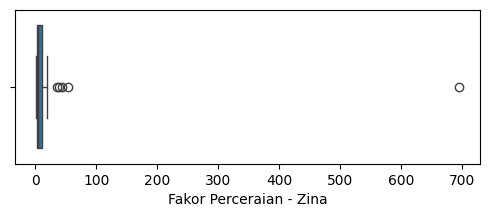

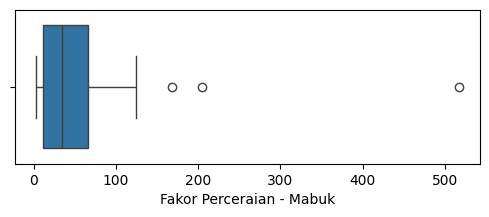

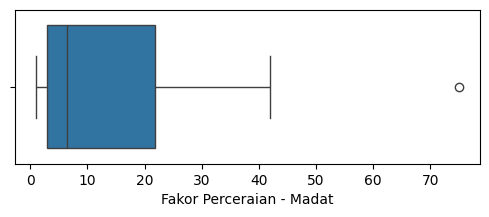

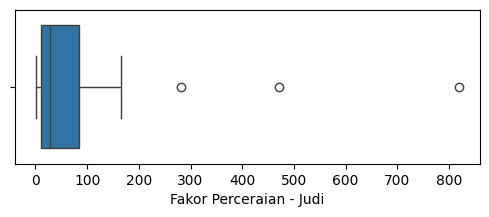

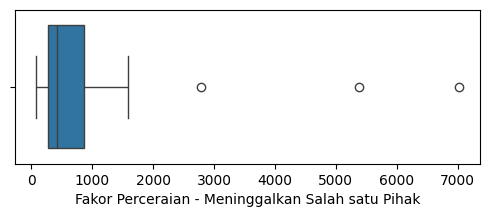

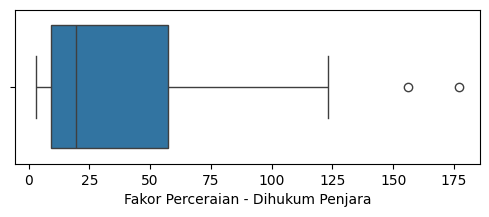

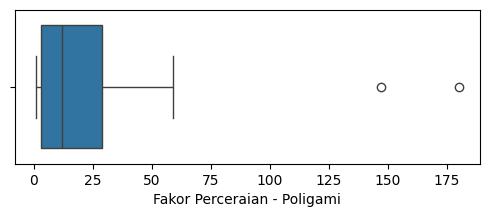

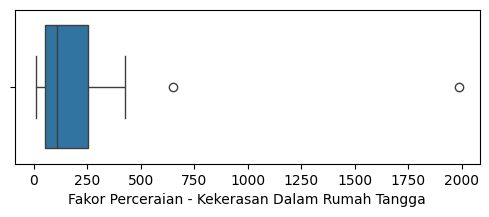

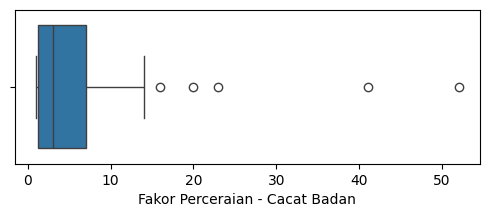

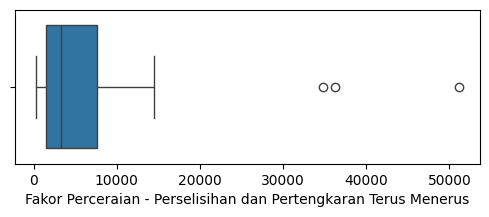

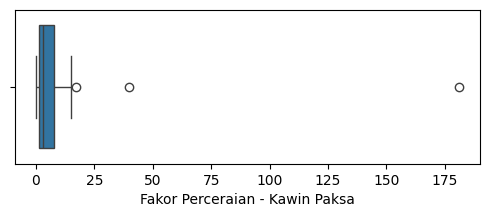

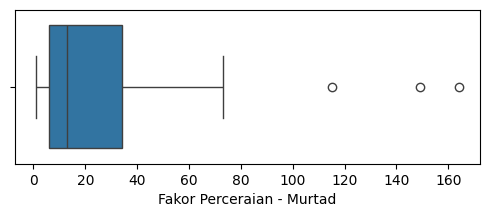

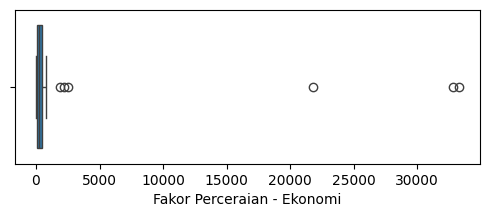

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in clean_df[faktor_cols]:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=col, data=clean_df)
    plt.xlabel(col)
    plt.show()

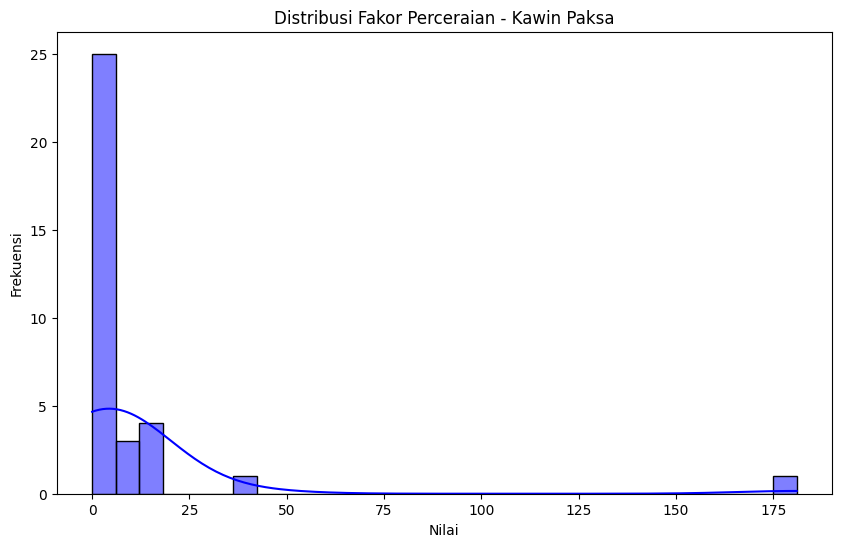

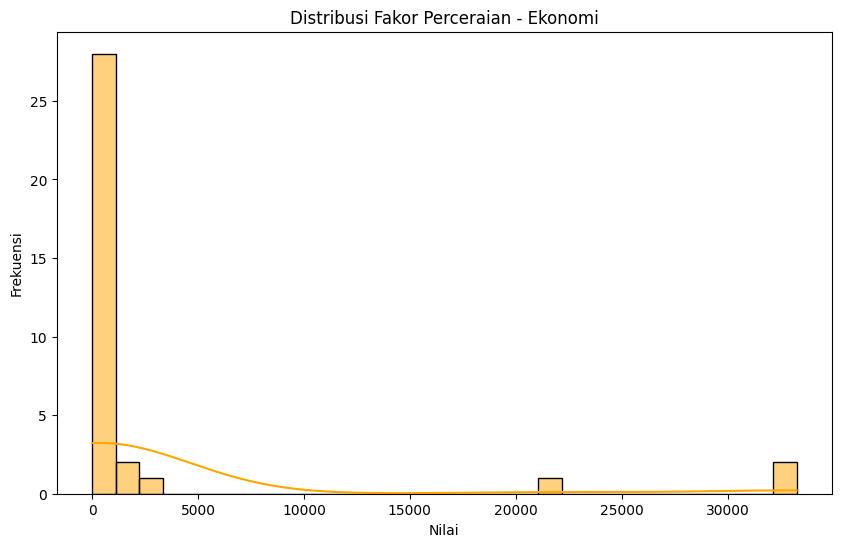

In [ ]:
# Distribusi Kawin Paksa
plt.figure(figsize=(10, 6))
sns.histplot(clean_df["Fakor Perceraian - Kawin Paksa"], kde=True, bins=30, color="blue")
plt.title("Distribusi Fakor Perceraian - Kawin Paksa")
plt.xlabel("Nilai")
plt.ylabel("Frekuensi")
plt.show()

# Distribusi Ekonomi
plt.figure(figsize=(10, 6))
sns.histplot(clean_df["Fakor Perceraian - Ekonomi"], kde=True, bins=30, color="orange")
plt.title("Distribusi Fakor Perceraian - Ekonomi")
plt.xlabel("Nilai")
plt.ylabel("Frekuensi")
plt.show()


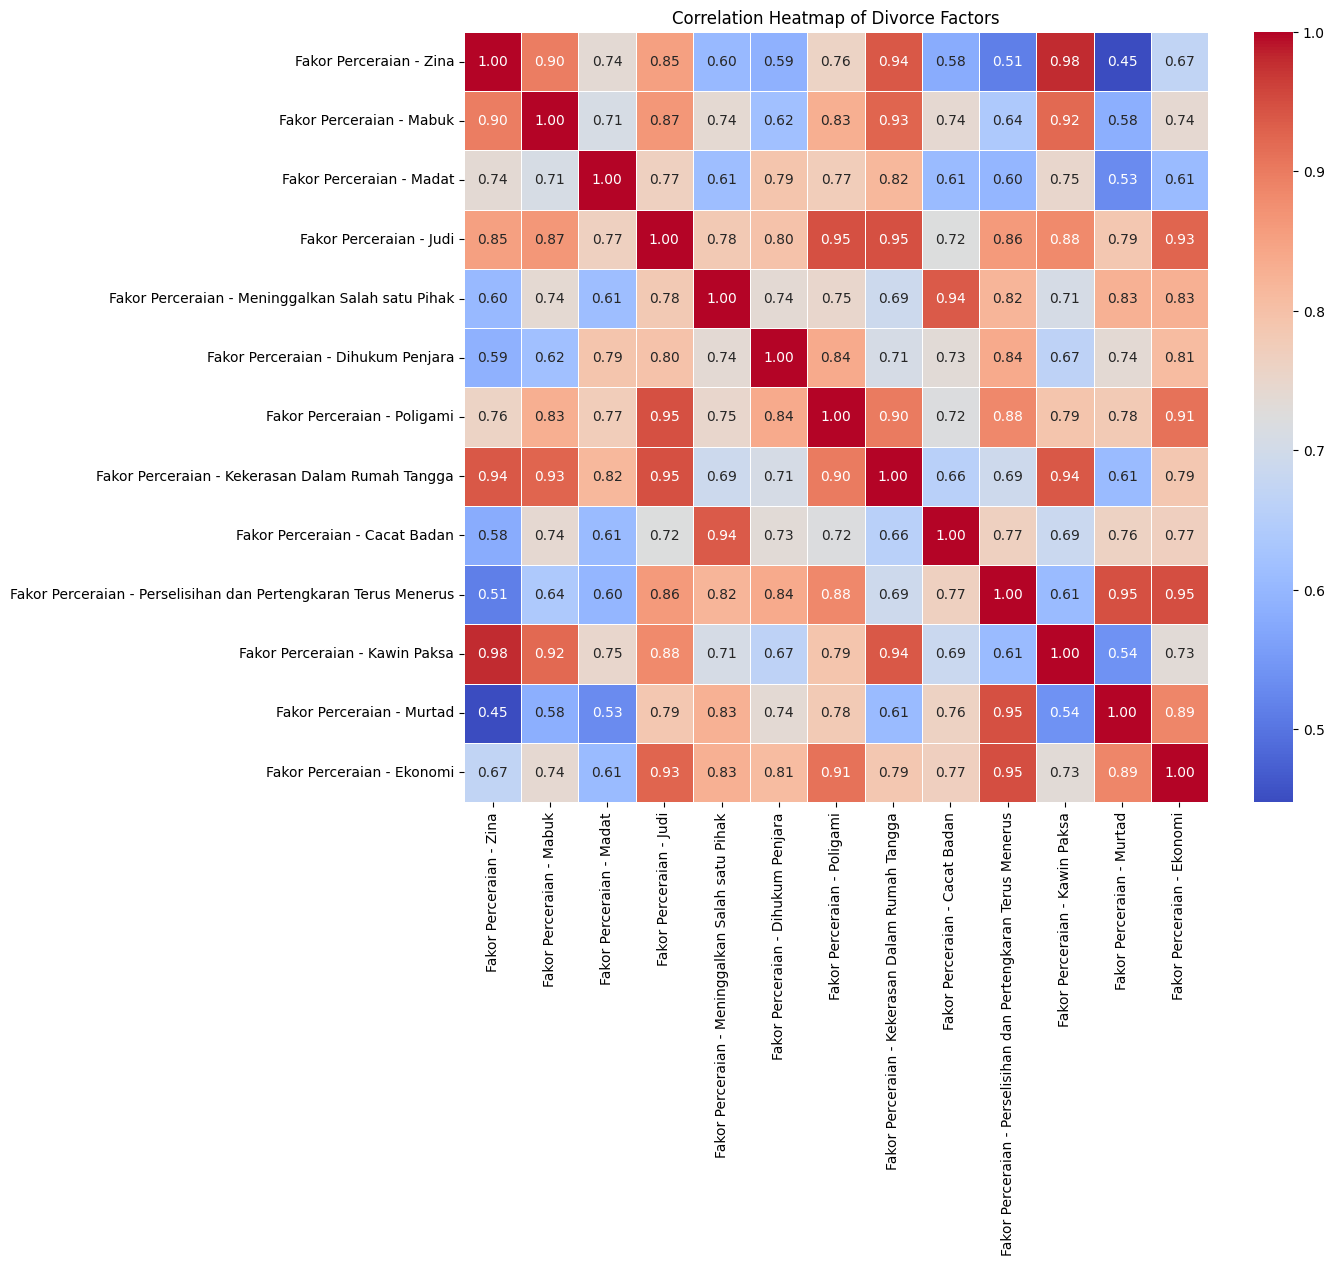

In [ ]:
# prompt: correlation heatmap

# Select only the columns with numerical data relevant to the correlation heatmap
corr_df = clean_df[faktor_cols]

# Calculate the correlation matrix
correlation_matrix = corr_df.corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Divorce Factors')
plt.show()

In [ ]:
corr_df

,Fakor Perceraian - Zina,Fakor Perceraian - Mabuk,Fakor Perceraian - Madat,Fakor Perceraian - Judi,Fakor Perceraian - Meninggalkan Salah satu Pihak,Fakor Perceraian - Dihukum Penjara,Fakor Perceraian - Poligami,Fakor Perceraian - Kekerasan Dalam Rumah Tangga,Fakor Perceraian - Cacat Badan,Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus,Fakor Perceraian - Kawin Paksa,Fakor Perceraian - Murtad,Fakor Perceraian - Ekonomi
0,6.0,10.0,18.0,26.0,551.0,61.0,28.0,122.0,16.0,5035.0,3.0,9.0,218.0
1,4.0,8.0,23.0,58.0,830.0,62.0,23.0,117.0,4.0,14454.0,15.0,73.0,299.0
2,2.0,7.0,5.0,30.0,936.0,29.0,22.0,100.0,6.0,6922.0,8.0,9.0,224.0
3,5.0,12.0,25.0,36.0,745.0,99.0,12.0,125.0,7.0,6922.0,5.0,18.0,231.0
4,4.0,20.0,30.0,46.0,375.0,34.0,9.0,77.0,1.0,3746.0,2.0,6.0,230.0
5,19.0,38.0,35.0,120.0,769.0,83.0,35.0,427.0,7.0,7851.0,10.0,18.0,778.0
6,2.0,8.0,4.0,26.0,263.0,18.0,6.0,85.0,1.0,2991.0,3.0,5.0,130.0
7,8.0,72.0,9.0,131.0,655.0,31.0,29.0,259.0,6.0,11195.0,14.0,40.0,2168.0
8,2.0,39.0,5.0,65.0,163.0,18.0,3.0,123.0,3.0,1601.0,2.0,6.0,268.0
9,10.0,14.0,6.0,22.0,311.0,23.0,3.0,93.0,2.0,2749.0,3.0,4.0,148.0


## Membuat fitur baru (faktor_cols)

mengubah nilai absolut (misalnya 300 kasus Zina) menjadi nilai relatif/proporsi terhadap total perceraian di provinsi tersebut. ini digunakan untuk menormalisasi antar provinsi yang besar dan kecil.

In [ ]:
df_fix = clean_df.copy()
df_fix

,Provinsi,Fakor Perceraian - Zina,Fakor Perceraian - Mabuk,Fakor Perceraian - Madat,Fakor Perceraian - Judi,Fakor Perceraian - Meninggalkan Salah satu Pihak,Fakor Perceraian - Dihukum Penjara,Fakor Perceraian - Poligami,Fakor Perceraian - Kekerasan Dalam Rumah Tangga,Fakor Perceraian - Cacat Badan,Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus,Fakor Perceraian - Kawin Paksa,Fakor Perceraian - Murtad,Fakor Perceraian - Ekonomi,Fakor Perceraian - Jumlah
0,Aceh,6.0,10.0,18.0,26.0,551.0,61.0,28.0,122.0,16.0,5035.0,3.0,9.0,218.0,6103.0
1,Sumatera Utara,4.0,8.0,23.0,58.0,830.0,62.0,23.0,117.0,4.0,14454.0,15.0,73.0,299.0,15955.0
2,Sumatera Barat,2.0,7.0,5.0,30.0,936.0,29.0,22.0,100.0,6.0,6922.0,8.0,9.0,224.0,8292.0
3,Riau,5.0,12.0,25.0,36.0,745.0,99.0,12.0,125.0,7.0,6922.0,5.0,18.0,231.0,8242.0
4,Jambi,4.0,20.0,30.0,46.0,375.0,34.0,9.0,77.0,1.0,3746.0,2.0,6.0,230.0,4580.0
5,Sumatera Selatan,19.0,38.0,35.0,120.0,769.0,83.0,35.0,427.0,7.0,7851.0,10.0,18.0,778.0,10180.0
6,Bengkulu,2.0,8.0,4.0,26.0,263.0,18.0,6.0,85.0,1.0,2991.0,3.0,5.0,130.0,3539.0
7,Lampung,8.0,72.0,9.0,131.0,655.0,31.0,29.0,259.0,6.0,11195.0,14.0,40.0,2168.0,14603.0
8,Kepulauan Bangka Belitung,2.0,39.0,5.0,65.0,163.0,18.0,3.0,123.0,3.0,1601.0,2.0,6.0,268.0,2291.0
9,Kepulauan Riau,10.0,14.0,6.0,22.0,311.0,23.0,3.0,93.0,2.0,2749.0,3.0,4.0,148.0,3385.0


In [ ]:
# Daftar kolom faktor perceraian (kecuali "Jumlah" dan "Provinsi")
faktor_cols = [col for col in df_fix.columns if "Fakor Perceraian" in col and "Jumlah" not in col]

# Buat kolom rasio
for col in faktor_cols:
    df_fix.loc[:, col + "_ratio"] = df_fix[col] / df_fix["Fakor Perceraian - Jumlah"]

# Sekarang buat daftar kolom rasio
ratio_cols = [col + "_ratio" for col in faktor_cols]

In [ ]:
df_fix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, 0 to 34
Data columns (total 28 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Provinsi                                                              34 non-null     object 
 1   Fakor Perceraian - Zina                                               34 non-null     float64
 2   Fakor Perceraian - Mabuk                                              34 non-null     float64
 3   Fakor Perceraian - Madat                                              34 non-null     float64
 4   Fakor Perceraian - Judi                                               34 non-null     float64
 5   Fakor Perceraian - Meninggalkan Salah satu Pihak                      34 non-null     float64
 6   Fakor Perceraian - Dihukum Penjara                                    34 non-null     float64
 7   Fakor 

In [ ]:
df_fix[ratio_cols]

,Fakor Perceraian - Zina_ratio,Fakor Perceraian - Mabuk_ratio,Fakor Perceraian - Madat_ratio,Fakor Perceraian - Judi_ratio,Fakor Perceraian - Meninggalkan Salah satu Pihak_ratio,Fakor Perceraian - Dihukum Penjara_ratio,Fakor Perceraian - Poligami_ratio,Fakor Perceraian - Kekerasan Dalam Rumah Tangga_ratio,Fakor Perceraian - Cacat Badan_ratio,Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus_ratio,Fakor Perceraian - Kawin Paksa_ratio,Fakor Perceraian - Murtad_ratio,Fakor Perceraian - Ekonomi_ratio
0,0.000983,0.001639,0.002949,0.004260,0.090283,0.009995,0.004588,0.019990,0.002622,0.825004,0.000492,0.001475,0.035720
1,0.000251,0.000501,0.001442,0.003635,0.052021,0.003886,0.001442,0.007333,0.000251,0.905923,0.000940,0.004575,0.018740
2,0.000241,0.000844,0.000603,0.003618,0.112880,0.003497,0.002653,0.012060,0.000724,0.834781,0.000965,0.001085,0.027014
3,0.000607,0.001456,0.003033,0.004368,0.090391,0.012012,0.001456,0.015166,0.000849,0.839845,0.000607,0.002184,0.028027
4,0.000873,0.004367,0.006550,0.010044,0.081878,0.007424,0.001965,0.016812,0.000218,0.817904,0.000437,0.001310,0.050218
5,0.001866,0.003733,0.003438,0.011788,0.075540,0.008153,0.003438,0.041945,0.000688,0.771218,0.000982,0.001768,0.076424
6,0.000565,0.002261,0.001130,0.007347,0.074315,0.005086,0.001695,0.024018,0.000283,0.845154,0.000848,0.001413,0.036734
7,0.000548,0.004930,0.000616,0.008971,0.044854,0.002123,0.001986,0.017736,0.000411,0.766623,0.000959,0.002739,0.148463
8,0.000873,0.017023,0.002182,0.028372,0.071148,0.007857,0.001309,0.053688,0.001309,0.698821,0.000873,0.002619,0.116979
9,0.002954,0.004136,0.001773,0.006499,0.091876,0.006795,0.000886,0.027474,0.000591,0.812112,0.000886,0.001182,0.043722


## Standarisasi

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_fix[ratio_cols])

In [ ]:
X_scaled

array([[-4.03215038e-01, -8.87767854e-01,  5.78328758e-01,
        -6.29264200e-01, -4.29496056e-01,  9.92560623e-01,
         9.12549850e-01, -6.25129875e-01,  1.85560167e+00,
         9.09309605e-01, -6.92690996e-01, -6.45329126e-01,
        -4.84643353e-01],
       [-8.10286583e-01, -9.96040717e-01, -3.92195443e-01,
        -7.44201042e-01, -1.06927991e+00, -4.85964396e-01,
        -7.27113581e-01, -1.33812008e+00, -9.78467892e-01,
         1.69967275e+00,  3.10698030e-02, -1.98472754e-02,
        -6.51874796e-01],
       [-8.15571477e-01, -9.63402848e-01, -9.31947548e-01,
        -7.47378766e-01, -5.16599958e-02, -5.80008283e-01,
        -9.57080239e-02, -1.07185845e+00, -4.13216727e-01,
         1.00479937e+00,  7.08268486e-02, -7.23860440e-01,
        -5.70388210e-01],
       [-6.12456125e-01, -9.05152509e-01,  6.32316096e-01,
        -6.09462671e-01, -4.27703312e-01,  1.48060507e+00,
        -7.19607767e-01, -8.96870010e-01, -2.62940837e-01,
         1.05426310e+00, -5.07004562e

## Penentuan jumlah klaster dengan elbow method dan silhoutte score

### KMeans

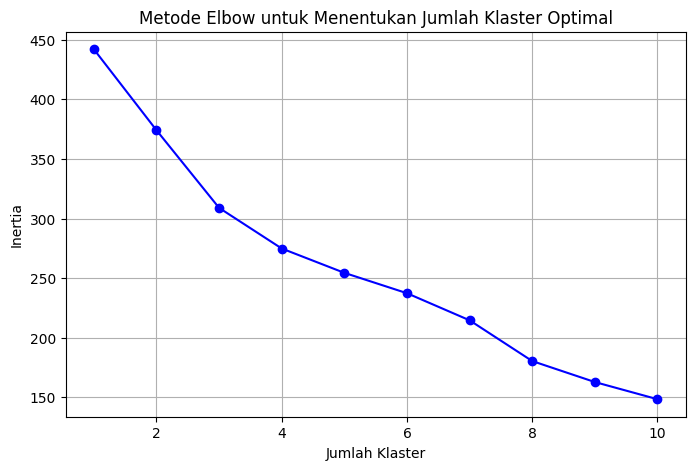

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Jumlah Klaster')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk Menentukan Jumlah Klaster Optimal')
plt.grid(True)
plt.show()

0.16489053581487795
0.15796420033231065
0.14749412637787765
0.14621755189764526
0.09185151823252544
0.10480522571185842
0.1426160903072942
0.1397978332964667
0.13773669026907429


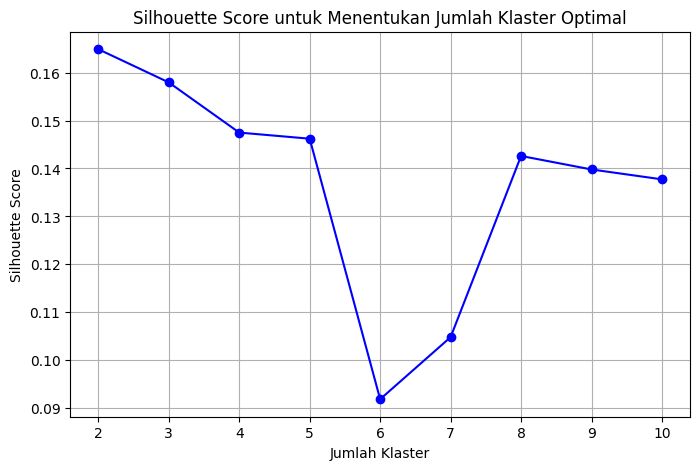

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []
K = range(2, 11)  # silhouette tidak bisa dihitung untuk k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    score = silhouette_score(X_scaled, labels)
    print(score)
    silhouette_scores.append(score)

# Plot hasilnya
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, 'bo-')
plt.xlabel('Jumlah Klaster')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Menentukan Jumlah Klaster Optimal')
plt.grid(True)
plt.show()

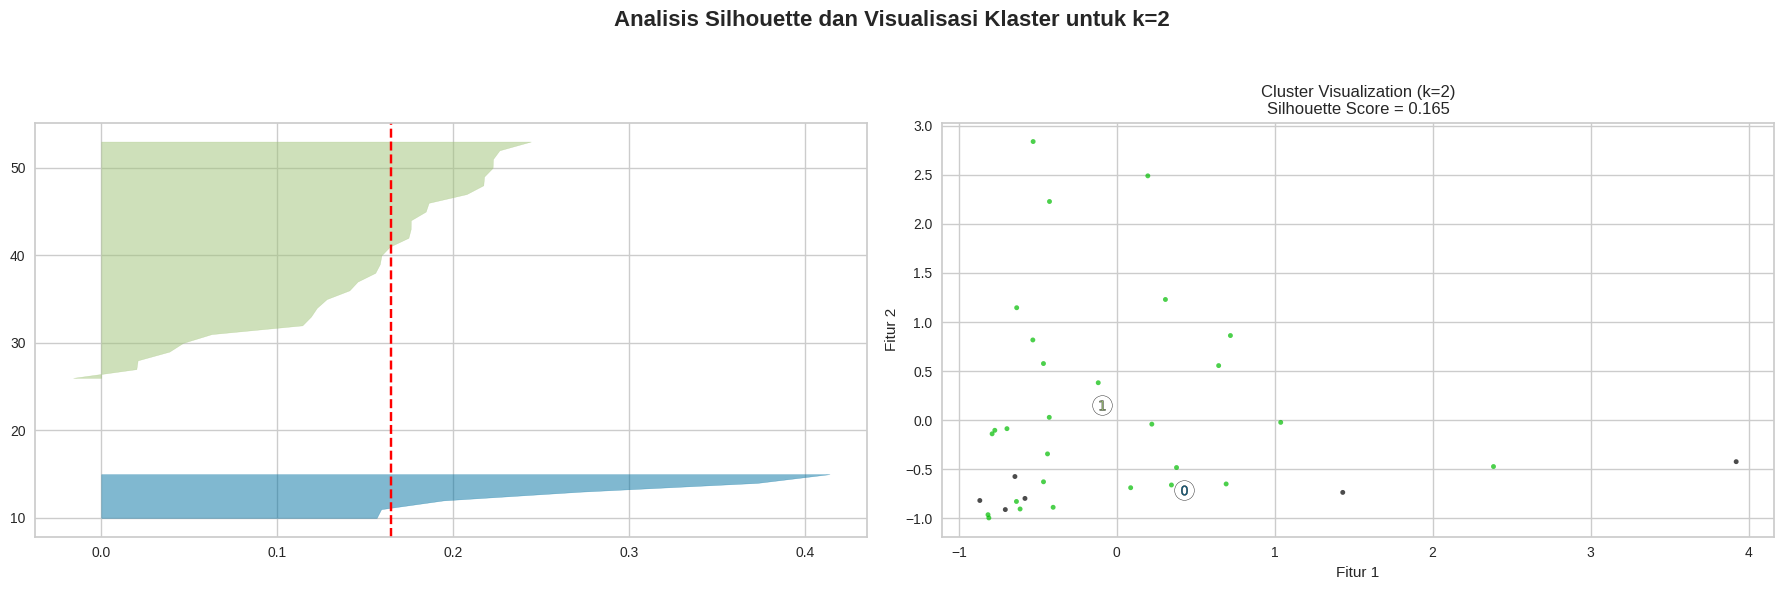

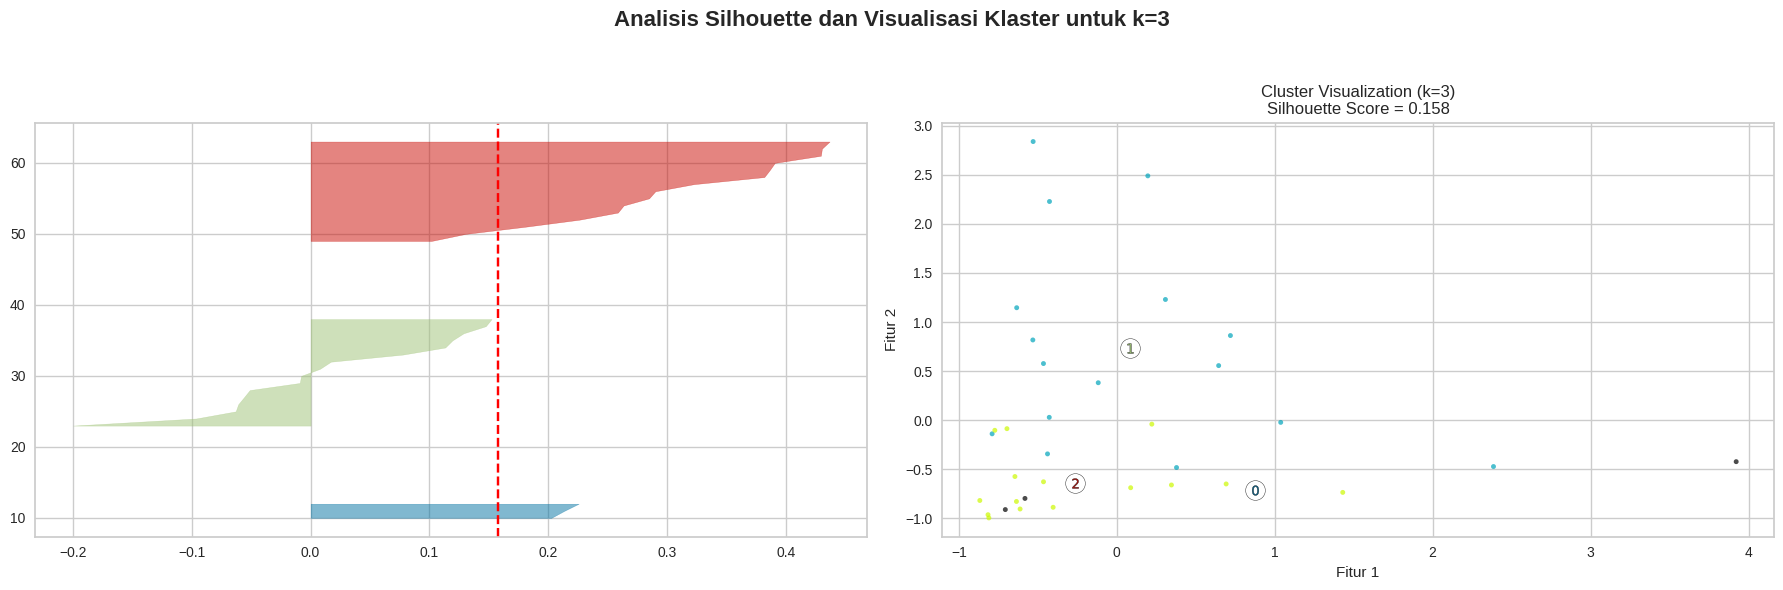

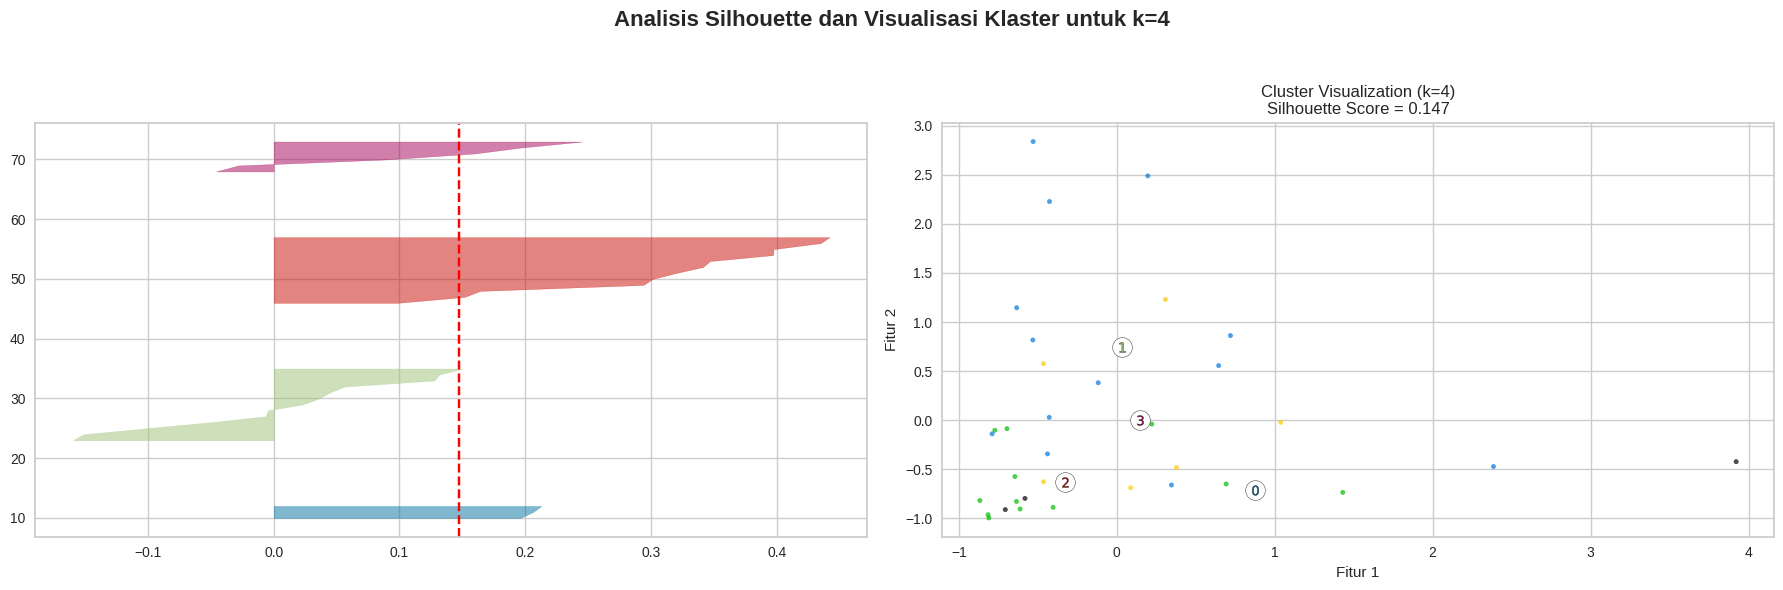

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

K_to_visualize = [2, 3, 4]

for k in K_to_visualize:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # ===== SilhouetteVisualizer (Yellowbrick)
    kmeans = KMeans(n_clusters=k, random_state=42)
    visualizer = SilhouetteVisualizer(kmeans, ax=ax1, colors='yellowbrick')
    visualizer.fit(X_scaled)

    # ===== Scatter plot cluster hasil KMeans
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_scaled, labels)

    # Plot cluster
    colors = cm.nipy_spectral(labels.astype(float) / k)
    ax2.scatter(
        X_scaled[:, 0], X_scaled[:, 1], marker='.', s=50, lw=0, alpha=0.7, c=colors, edgecolor='k'
    )

    # Plot cluster centers
    centers = kmeans.cluster_centers_
    ax2.scatter(
        centers[:, 0], centers[:, 1],
        marker='o', c='white', alpha=1, s=200, edgecolor='k'
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title(f"Cluster Visualization (k={k})\nSilhouette Score = {silhouette_avg:.3f}")
    ax2.set_xlabel("Fitur 1")
    ax2.set_ylabel("Fitur 2")
    ax2.grid(True)

    plt.suptitle(f"Analisis Silhouette dan Visualisasi Klaster untuk k={k}", fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

berarti pakai 2 cluster

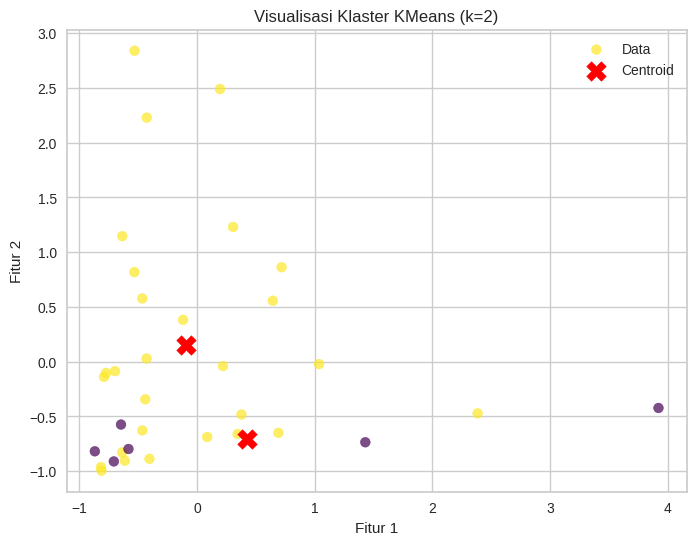

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Jalankan KMeans dengan k=2
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

# Ambil label klaster dan centroid
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Scatter plot data
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7, label='Data')

# Plot centroid-nya
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroid')

# Label dan judul
plt.xlabel('Fitur 1')  # Ganti dengan nama asli fitur jika ada
plt.ylabel('Fitur 2')  # Ganti juga jika perlu
plt.title('Visualisasi Klaster KMeans (k=2)')
plt.legend()
plt.grid(True)
plt.show()

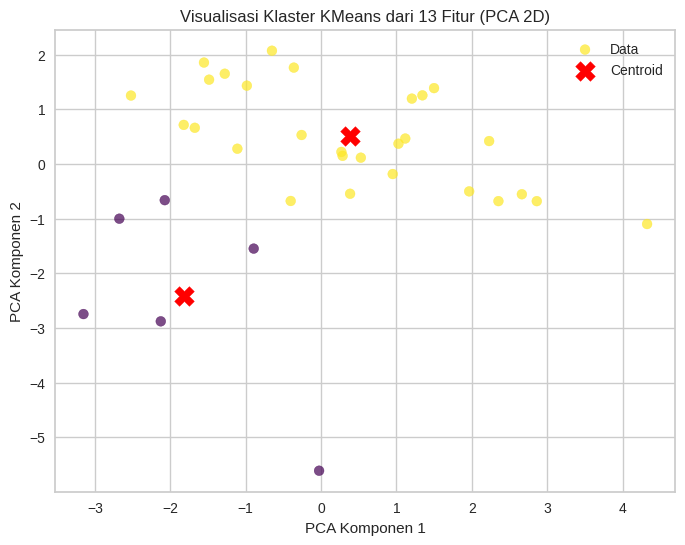

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Fit KMeans pada seluruh fitur (13 fitur)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_

# Reduksi dimensi ke 2D hanya untuk visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_2d = pca.transform(kmeans.cluster_centers_)

# Visualisasi
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7, label='Data')
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='red', s=200, marker='X', label='Centroid')
plt.title('Visualisasi Klaster KMeans dari 13 Fitur (PCA 2D)')
plt.xlabel('PCA Komponen 1')
plt.ylabel('PCA Komponen 2')
plt.legend()
plt.grid(True)
plt.show()

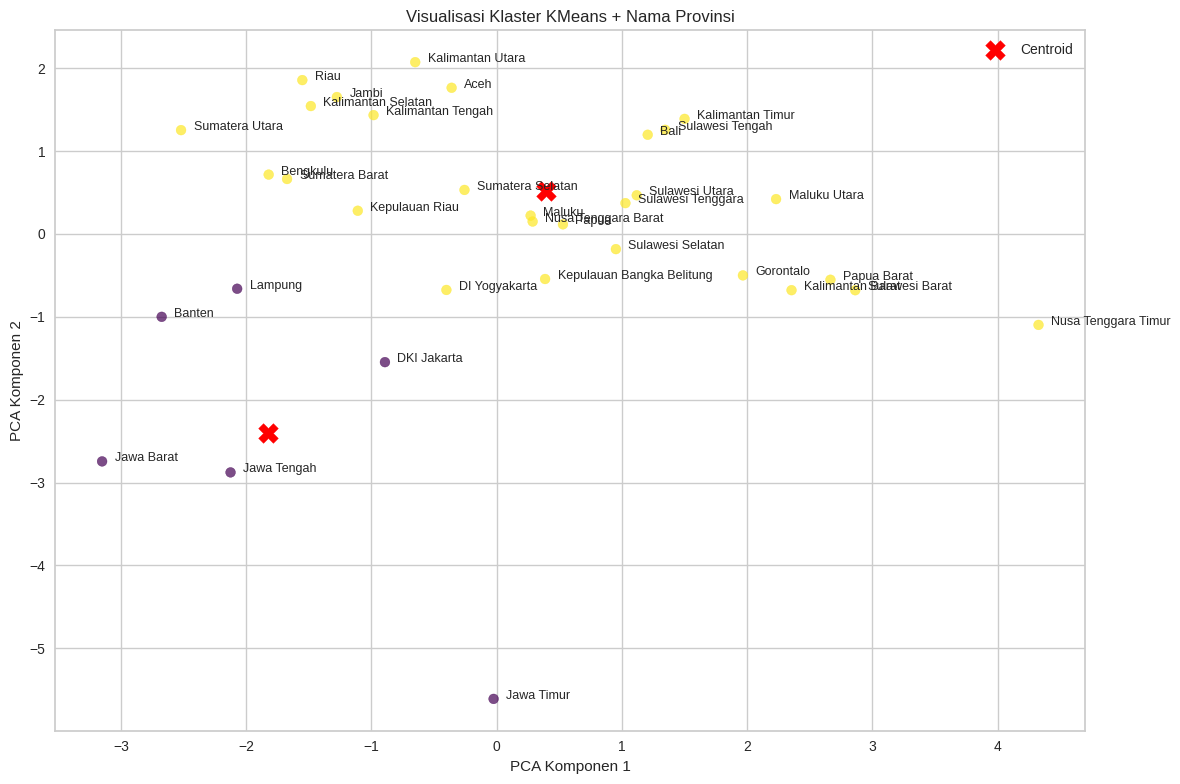

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Asumsikan kamu punya:
# - X_scaled : data fitur yang sudah distandarisasi (13 fitur)
# - df : dataframe aslinya yang punya kolom "Provinsi"

# Langkah 1: KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_

# Langkah 2: PCA untuk visualisasi (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_2d = pca.transform(kmeans.cluster_centers_)

# Langkah 3: Plot scatter
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)

for i in range(len(X_pca)):
    df = clean_df.reset_index(drop=True)
    prov = df.iloc[i]['Provinsi']
    plt.text(X_pca[i, 0]+0.1, X_pca[i, 1], prov, fontsize=9)


# Plot centroid
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='red', s=200, marker='X', label='Centroid')

plt.title('Visualisasi Klaster KMeans + Nama Provinsi')
plt.xlabel('PCA Komponen 1')
plt.ylabel('PCA Komponen 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### DBSACAN

eps=0.1, unique labels={np.int64(-1)}, total clusters=0
eps=0.3, unique labels={np.int64(-1)}, total clusters=0
eps=0.5, unique labels={np.int64(-1)}, total clusters=0
eps=0.7, unique labels={np.int64(-1)}, total clusters=0
eps=0.9, unique labels={np.int64(-1)}, total clusters=0
eps=1.1, unique labels={np.int64(-1)}, total clusters=0
eps=1.3, unique labels={np.int64(-1)}, total clusters=0
eps=1.5, unique labels={np.int64(0), np.int64(-1)}, total clusters=1
eps=1.7, unique labels={np.int64(0), np.int64(-1)}, total clusters=1
eps=1.9, unique labels={np.int64(0), np.int64(1), np.int64(-1)}, total clusters=2
eps=2.1, unique labels={np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}, total clusters=3
eps=2.3, unique labels={np.int64(0), np.int64(1), np.int64(-1)}, total clusters=2
eps=2.5, unique labels={np.int64(0), np.int64(1), np.int64(-1)}, total clusters=2
eps=2.7, unique labels={np.int64(0), np.int64(1), np.int64(-1)}, total clusters=2
eps=2.9, unique labels={np.int64(0), np.int64(1

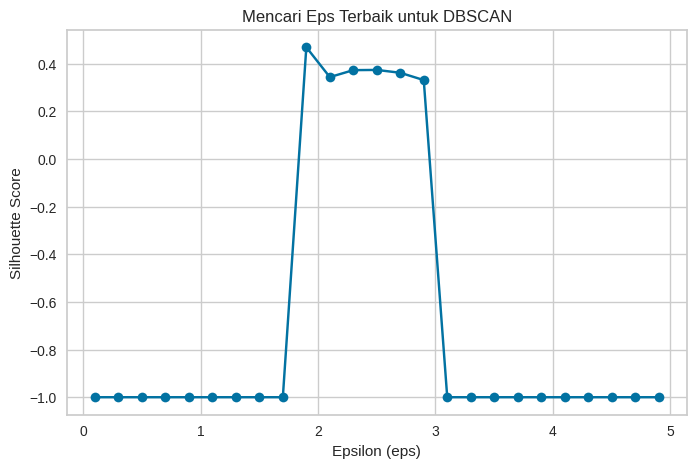


Hasil Silhouette Score untuk setiap epsilon:
eps = 0.1, silhouette score = -1.0000
eps = 0.3, silhouette score = -1.0000
eps = 0.5, silhouette score = -1.0000
eps = 0.7, silhouette score = -1.0000
eps = 0.9, silhouette score = -1.0000
eps = 1.1, silhouette score = -1.0000
eps = 1.3, silhouette score = -1.0000
eps = 1.5, silhouette score = -1.0000
eps = 1.7, silhouette score = -1.0000
eps = 1.9, silhouette score = 0.4691
eps = 2.1, silhouette score = 0.3437
eps = 2.3, silhouette score = 0.3729
eps = 2.5, silhouette score = 0.3738
eps = 2.7, silhouette score = 0.3618
eps = 2.9, silhouette score = 0.3312
eps = 3.1, silhouette score = -1.0000
eps = 3.3, silhouette score = -1.0000
eps = 3.5, silhouette score = -1.0000
eps = 3.7, silhouette score = -1.0000
eps = 3.9, silhouette score = -1.0000
eps = 4.1, silhouette score = -1.0000
eps = 4.3, silhouette score = -1.0000
eps = 4.5, silhouette score = -1.0000
eps = 4.7, silhouette score = -1.0000
eps = 4.9, silhouette score = -1.0000


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt  # jangan lupa import ini kalau belum

# Contoh range untuk mencari eps optimal
eps_values = np.arange(0.1, 5.0, 0.2)
silhouette_scores = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=2)
    labels = dbscan.fit_predict(X_scaled)

    # Filter out noise (-1) before calculating silhouette
    if len(set(labels)) - (1 if -1 in labels else 0) > 1:
        mask = labels != -1
        score = silhouette_score(X_scaled[mask], labels[mask])
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(-1)

    print(f"eps={eps:.1f}, unique labels={set(labels)}, total clusters={len(set(labels) - {-1})}")

# Plot Silhouette Score per epsilon
plt.figure(figsize=(8, 5))
plt.plot(eps_values, silhouette_scores, marker='o')
plt.xlabel('Epsilon (eps)')
plt.ylabel('Silhouette Score')
plt.title('Mencari Eps Terbaik untuk DBSCAN')
plt.grid(True)
plt.show()

# Menampilkan hasil silhouette score
print("\nHasil Silhouette Score untuk setiap epsilon:")
for eps, score in zip(eps_values, silhouette_scores):
    print(f"eps = {eps:.1f}, silhouette score = {score:.4f}")

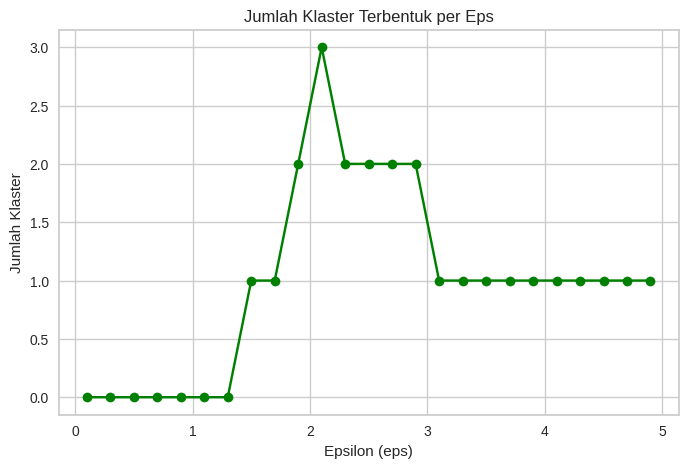

In [ ]:
cluster_counts = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=2)
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    cluster_counts.append(n_clusters)

plt.figure(figsize=(8, 5))
plt.plot(eps_values, cluster_counts, marker='o', color='green')
plt.xlabel('Epsilon (eps)')
plt.ylabel('Jumlah Klaster')
plt.title('Jumlah Klaster Terbentuk per Eps')
plt.grid(True)
plt.show()

berarti pakai 2 cluster

### Silhoutte score

eps=0.1, unique labels={np.int64(-1)}, total clusters=0
eps=0.3, unique labels={np.int64(-1)}, total clusters=0
eps=0.5, unique labels={np.int64(-1)}, total clusters=0
eps=0.7, unique labels={np.int64(-1)}, total clusters=0
eps=0.9, unique labels={np.int64(-1)}, total clusters=0
eps=1.1, unique labels={np.int64(-1)}, total clusters=0
eps=1.3, unique labels={np.int64(-1)}, total clusters=0
eps=1.5, unique labels={np.int64(0), np.int64(-1)}, total clusters=1
eps=1.7, unique labels={np.int64(0), np.int64(-1)}, total clusters=1
eps=1.9, unique labels={np.int64(0), np.int64(1), np.int64(-1)}, total clusters=2
eps=2.1, unique labels={np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}, total clusters=3
eps=2.3, unique labels={np.int64(0), np.int64(1), np.int64(-1)}, total clusters=2
eps=2.5, unique labels={np.int64(0), np.int64(1), np.int64(-1)}, total clusters=2
eps=2.7, unique labels={np.int64(0), np.int64(1), np.int64(-1)}, total clusters=2
eps=2.9, unique labels={np.int64(0), np.int64(1

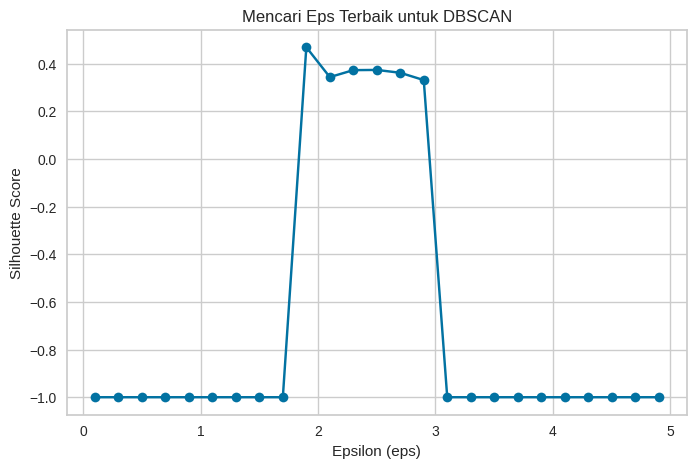


Hasil Silhouette Score untuk setiap epsilon:
eps = 0.1, silhouette score = -1.0000
eps = 0.3, silhouette score = -1.0000
eps = 0.5, silhouette score = -1.0000
eps = 0.7, silhouette score = -1.0000
eps = 0.9, silhouette score = -1.0000
eps = 1.1, silhouette score = -1.0000
eps = 1.3, silhouette score = -1.0000
eps = 1.5, silhouette score = -1.0000
eps = 1.7, silhouette score = -1.0000
eps = 1.9, silhouette score = 0.4691
eps = 2.1, silhouette score = 0.3437
eps = 2.3, silhouette score = 0.3729
eps = 2.5, silhouette score = 0.3738
eps = 2.7, silhouette score = 0.3618
eps = 2.9, silhouette score = 0.3312
eps = 3.1, silhouette score = -1.0000
eps = 3.3, silhouette score = -1.0000
eps = 3.5, silhouette score = -1.0000
eps = 3.7, silhouette score = -1.0000
eps = 3.9, silhouette score = -1.0000
eps = 4.1, silhouette score = -1.0000
eps = 4.3, silhouette score = -1.0000
eps = 4.5, silhouette score = -1.0000
eps = 4.7, silhouette score = -1.0000
eps = 4.9, silhouette score = -1.0000


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt  # jangan lupa import ini kalau belum

# Contoh range untuk mencari eps optimal
eps_values = np.arange(0.1, 5.0, 0.2)
silhouette_scores = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=2)
    labels = dbscan.fit_predict(X_scaled)

    # Filter out noise (-1) before calculating silhouette
    if len(set(labels)) - (1 if -1 in labels else 0) > 1:
        mask = labels != -1
        score = silhouette_score(X_scaled[mask], labels[mask])
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(-1)

    print(f"eps={eps:.1f}, unique labels={set(labels)}, total clusters={len(set(labels) - {-1})}")

# Plot Silhouette Score per epsilon
plt.figure(figsize=(8, 5))
plt.plot(eps_values, silhouette_scores, marker='o')
plt.xlabel('Epsilon (eps)')
plt.ylabel('Silhouette Score')
plt.title('Mencari Eps Terbaik untuk DBSCAN')
plt.grid(True)
plt.show()

# Menampilkan hasil silhouette score
print("\nHasil Silhouette Score untuk setiap epsilon:")
for eps, score in zip(eps_values, silhouette_scores):
    print(f"eps = {eps:.1f}, silhouette score = {score:.4f}")

k = 2, silhouette score = 0.1649
k = 3, silhouette score = 0.1580
k = 4, silhouette score = 0.1475
k = 5, silhouette score = 0.1462
k = 6, silhouette score = 0.0919
k = 7, silhouette score = 0.1048
k = 8, silhouette score = 0.1426
k = 9, silhouette score = 0.1398
k = 10, silhouette score = 0.1377


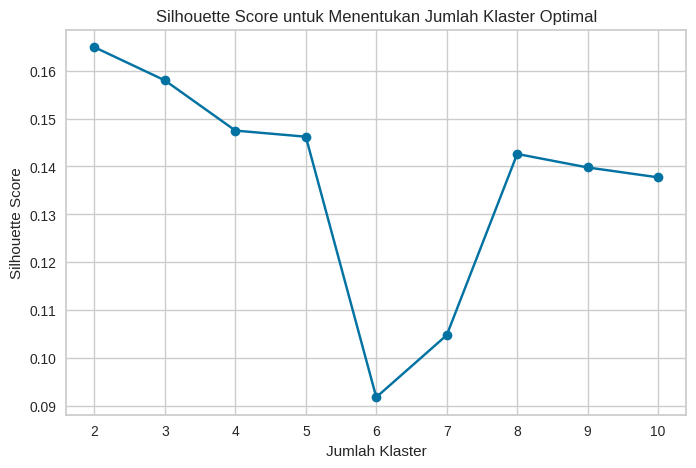

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []
K = range(2, 11)  # silhouette tidak bisa dihitung untuk k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"k = {k}, silhouette score = {score:.4f}")

# Plot hasilnya
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, 'bo-')
plt.xlabel('Jumlah Klaster')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Menentukan Jumlah Klaster Optimal')
plt.grid(True)
plt.show()

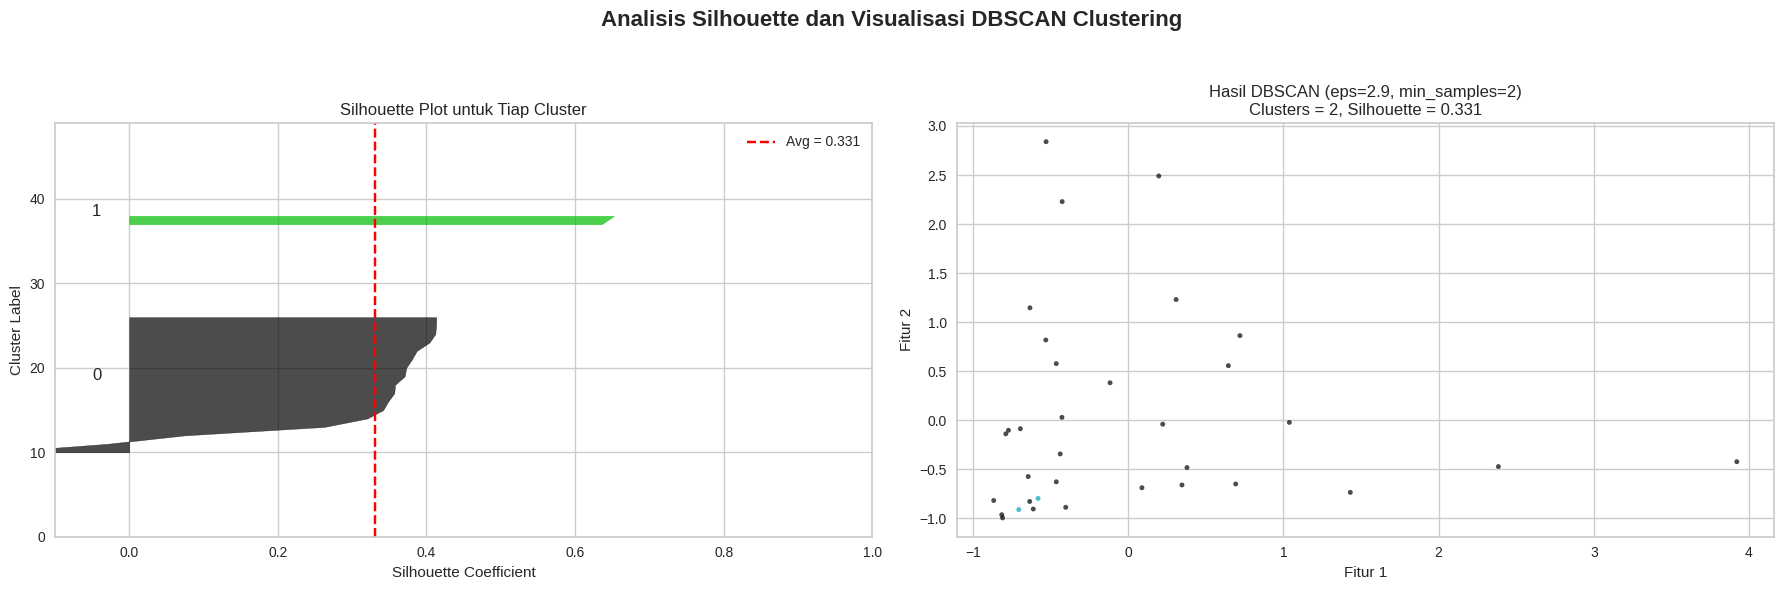

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set DBSCAN parameter
eps = 2.9
min_samples = 2

# Jalankan DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

# Identifikasi cluster valid
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

if n_clusters > 1:
    # Hitung silhouette
    silhouette_avg = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
    sample_silhouette_values = silhouette_samples(X_scaled[labels != -1], labels[labels != -1])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Silhouette plot manual
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled[labels != -1]) + (n_clusters + 1) * 10])

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[labels[labels != -1] == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Silhouette Plot untuk Tiap Cluster")
    ax1.set_xlabel("Silhouette Coefficient")
    ax1.set_ylabel("Cluster Label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Avg = {silhouette_avg:.3f}")
    ax1.legend()
    ax1.grid(True)

    # Scatter plot hasil clustering
    colors = cm.nipy_spectral(labels.astype(float) / (n_clusters + 1))
    ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], marker='.', s=50, lw=0, alpha=0.7, c=colors, edgecolor='k')
    ax2.set_title(f"Hasil DBSCAN (eps={eps}, min_samples={min_samples})\nClusters = {n_clusters}, Silhouette = {silhouette_avg:.3f}")
    ax2.set_xlabel("Fitur 1")
    ax2.set_ylabel("Fitur 2")
    ax2.grid(True)

    plt.suptitle(f"Analisis Silhouette dan Visualisasi DBSCAN Clustering", fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

else:
    print(f"Tidak cukup cluster untuk menghitung silhouette (clusters ditemukan: {n_clusters})")


# Modelling

In [ ]:
clean_df

,Provinsi,Fakor Perceraian - Zina,Fakor Perceraian - Mabuk,Fakor Perceraian - Madat,Fakor Perceraian - Judi,Fakor Perceraian - Meninggalkan Salah satu Pihak,Fakor Perceraian - Dihukum Penjara,Fakor Perceraian - Poligami,Fakor Perceraian - Kekerasan Dalam Rumah Tangga,Fakor Perceraian - Cacat Badan,Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus,Fakor Perceraian - Kawin Paksa,Fakor Perceraian - Murtad,Fakor Perceraian - Ekonomi,Fakor Perceraian - Jumlah
0,Aceh,6.0,10.0,18.0,26.0,551.0,61.0,28.0,122.0,16.0,5035.0,3.0,9.0,218.0,6103.0
1,Sumatera Utara,4.0,8.0,23.0,58.0,830.0,62.0,23.0,117.0,4.0,14454.0,15.0,73.0,299.0,15955.0
2,Sumatera Barat,2.0,7.0,5.0,30.0,936.0,29.0,22.0,100.0,6.0,6922.0,8.0,9.0,224.0,8292.0
3,Riau,5.0,12.0,25.0,36.0,745.0,99.0,12.0,125.0,7.0,6922.0,5.0,18.0,231.0,8242.0
4,Jambi,4.0,20.0,30.0,46.0,375.0,34.0,9.0,77.0,1.0,3746.0,2.0,6.0,230.0,4580.0
5,Sumatera Selatan,19.0,38.0,35.0,120.0,769.0,83.0,35.0,427.0,7.0,7851.0,10.0,18.0,778.0,10180.0
6,Bengkulu,2.0,8.0,4.0,26.0,263.0,18.0,6.0,85.0,1.0,2991.0,3.0,5.0,130.0,3539.0
7,Lampung,8.0,72.0,9.0,131.0,655.0,31.0,29.0,259.0,6.0,11195.0,14.0,40.0,2168.0,14603.0
8,Kepulauan Bangka Belitung,2.0,39.0,5.0,65.0,163.0,18.0,3.0,123.0,3.0,1601.0,2.0,6.0,268.0,2291.0
9,Kepulauan Riau,10.0,14.0,6.0,22.0,311.0,23.0,3.0,93.0,2.0,2749.0,3.0,4.0,148.0,3385.0


## KMeans

In [ ]:
df_kmeans = clean_df.copy()
df_kmeans

,Provinsi,Fakor Perceraian - Zina,Fakor Perceraian - Mabuk,Fakor Perceraian - Madat,Fakor Perceraian - Judi,Fakor Perceraian - Meninggalkan Salah satu Pihak,Fakor Perceraian - Dihukum Penjara,Fakor Perceraian - Poligami,Fakor Perceraian - Kekerasan Dalam Rumah Tangga,Fakor Perceraian - Cacat Badan,Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus,Fakor Perceraian - Kawin Paksa,Fakor Perceraian - Murtad,Fakor Perceraian - Ekonomi,Fakor Perceraian - Jumlah
0,Aceh,6.0,10.0,18.0,26.0,551.0,61.0,28.0,122.0,16.0,5035.0,3.0,9.0,218.0,6103.0
1,Sumatera Utara,4.0,8.0,23.0,58.0,830.0,62.0,23.0,117.0,4.0,14454.0,15.0,73.0,299.0,15955.0
2,Sumatera Barat,2.0,7.0,5.0,30.0,936.0,29.0,22.0,100.0,6.0,6922.0,8.0,9.0,224.0,8292.0
3,Riau,5.0,12.0,25.0,36.0,745.0,99.0,12.0,125.0,7.0,6922.0,5.0,18.0,231.0,8242.0
4,Jambi,4.0,20.0,30.0,46.0,375.0,34.0,9.0,77.0,1.0,3746.0,2.0,6.0,230.0,4580.0
5,Sumatera Selatan,19.0,38.0,35.0,120.0,769.0,83.0,35.0,427.0,7.0,7851.0,10.0,18.0,778.0,10180.0
6,Bengkulu,2.0,8.0,4.0,26.0,263.0,18.0,6.0,85.0,1.0,2991.0,3.0,5.0,130.0,3539.0
7,Lampung,8.0,72.0,9.0,131.0,655.0,31.0,29.0,259.0,6.0,11195.0,14.0,40.0,2168.0,14603.0
8,Kepulauan Bangka Belitung,2.0,39.0,5.0,65.0,163.0,18.0,3.0,123.0,3.0,1601.0,2.0,6.0,268.0,2291.0
9,Kepulauan Riau,10.0,14.0,6.0,22.0,311.0,23.0,3.0,93.0,2.0,2749.0,3.0,4.0,148.0,3385.0


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
df_kmeans['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
df_kmeans

,Provinsi,Fakor Perceraian - Zina,Fakor Perceraian - Mabuk,Fakor Perceraian - Madat,Fakor Perceraian - Judi,Fakor Perceraian - Meninggalkan Salah satu Pihak,Fakor Perceraian - Dihukum Penjara,Fakor Perceraian - Poligami,Fakor Perceraian - Kekerasan Dalam Rumah Tangga,Fakor Perceraian - Cacat Badan,Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus,Fakor Perceraian - Kawin Paksa,Fakor Perceraian - Murtad,Fakor Perceraian - Ekonomi,Fakor Perceraian - Jumlah,Cluster
0,Aceh,6.0,10.0,18.0,26.0,551.0,61.0,28.0,122.0,16.0,5035.0,3.0,9.0,218.0,6103.0,1
1,Sumatera Utara,4.0,8.0,23.0,58.0,830.0,62.0,23.0,117.0,4.0,14454.0,15.0,73.0,299.0,15955.0,1
2,Sumatera Barat,2.0,7.0,5.0,30.0,936.0,29.0,22.0,100.0,6.0,6922.0,8.0,9.0,224.0,8292.0,1
3,Riau,5.0,12.0,25.0,36.0,745.0,99.0,12.0,125.0,7.0,6922.0,5.0,18.0,231.0,8242.0,1
4,Jambi,4.0,20.0,30.0,46.0,375.0,34.0,9.0,77.0,1.0,3746.0,2.0,6.0,230.0,4580.0,1
5,Sumatera Selatan,19.0,38.0,35.0,120.0,769.0,83.0,35.0,427.0,7.0,7851.0,10.0,18.0,778.0,10180.0,1
6,Bengkulu,2.0,8.0,4.0,26.0,263.0,18.0,6.0,85.0,1.0,2991.0,3.0,5.0,130.0,3539.0,1
7,Lampung,8.0,72.0,9.0,131.0,655.0,31.0,29.0,259.0,6.0,11195.0,14.0,40.0,2168.0,14603.0,0
8,Kepulauan Bangka Belitung,2.0,39.0,5.0,65.0,163.0,18.0,3.0,123.0,3.0,1601.0,2.0,6.0,268.0,2291.0,1
9,Kepulauan Riau,10.0,14.0,6.0,22.0,311.0,23.0,3.0,93.0,2.0,2749.0,3.0,4.0,148.0,3385.0,1


## DBSCAN

In [ ]:
df_dbscan = clean_df.copy()
df_dbscan

,Provinsi,Fakor Perceraian - Zina,Fakor Perceraian - Mabuk,Fakor Perceraian - Madat,Fakor Perceraian - Judi,Fakor Perceraian - Meninggalkan Salah satu Pihak,Fakor Perceraian - Dihukum Penjara,Fakor Perceraian - Poligami,Fakor Perceraian - Kekerasan Dalam Rumah Tangga,Fakor Perceraian - Cacat Badan,Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus,Fakor Perceraian - Kawin Paksa,Fakor Perceraian - Murtad,Fakor Perceraian - Ekonomi,Fakor Perceraian - Jumlah
0,Aceh,6.0,10.0,18.0,26.0,551.0,61.0,28.0,122.0,16.0,5035.0,3.0,9.0,218.0,6103.0
1,Sumatera Utara,4.0,8.0,23.0,58.0,830.0,62.0,23.0,117.0,4.0,14454.0,15.0,73.0,299.0,15955.0
2,Sumatera Barat,2.0,7.0,5.0,30.0,936.0,29.0,22.0,100.0,6.0,6922.0,8.0,9.0,224.0,8292.0
3,Riau,5.0,12.0,25.0,36.0,745.0,99.0,12.0,125.0,7.0,6922.0,5.0,18.0,231.0,8242.0
4,Jambi,4.0,20.0,30.0,46.0,375.0,34.0,9.0,77.0,1.0,3746.0,2.0,6.0,230.0,4580.0
5,Sumatera Selatan,19.0,38.0,35.0,120.0,769.0,83.0,35.0,427.0,7.0,7851.0,10.0,18.0,778.0,10180.0
6,Bengkulu,2.0,8.0,4.0,26.0,263.0,18.0,6.0,85.0,1.0,2991.0,3.0,5.0,130.0,3539.0
7,Lampung,8.0,72.0,9.0,131.0,655.0,31.0,29.0,259.0,6.0,11195.0,14.0,40.0,2168.0,14603.0
8,Kepulauan Bangka Belitung,2.0,39.0,5.0,65.0,163.0,18.0,3.0,123.0,3.0,1601.0,2.0,6.0,268.0,2291.0
9,Kepulauan Riau,10.0,14.0,6.0,22.0,311.0,23.0,3.0,93.0,2.0,2749.0,3.0,4.0,148.0,3385.0


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

best_result = None
for eps in np.arange(1.5, 3.0, 0.1):
    for min_samples in range(2, 6):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        if n_clusters > 1 and n_noise < (0.5 * len(X_scaled)):
            score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
            print(f"eps={eps:.1f}, min_samples={min_samples}, clusters={n_clusters}, noise={n_noise}, silhouette={score:.4f}")

            # Simpan hanya jika valid dan score lebih baik
            if not best_result or score > best_result[3]:
                best_result = (eps, min_samples, n_clusters, score, n_noise)

# Tambahan validasi agar tidak crash
if best_result:
    print(f"\n>> Best combination: eps={best_result[0]}, min_samples={best_result[1]}, clusters={best_result[2]}, silhouette={best_result[3]:.4f}, noise={best_result[4]}")
else:
    print("\n>> Tidak ada kombinasi yang memenuhi syarat (min 2 cluster dan max 30% noise)")

eps=2.8, min_samples=2, clusters=2, noise=15, silhouette=0.3312
eps=2.9, min_samples=2, clusters=2, noise=15, silhouette=0.3312

>> Best combination: eps=2.800000000000001, min_samples=2, clusters=2, silhouette=0.3312, noise=15


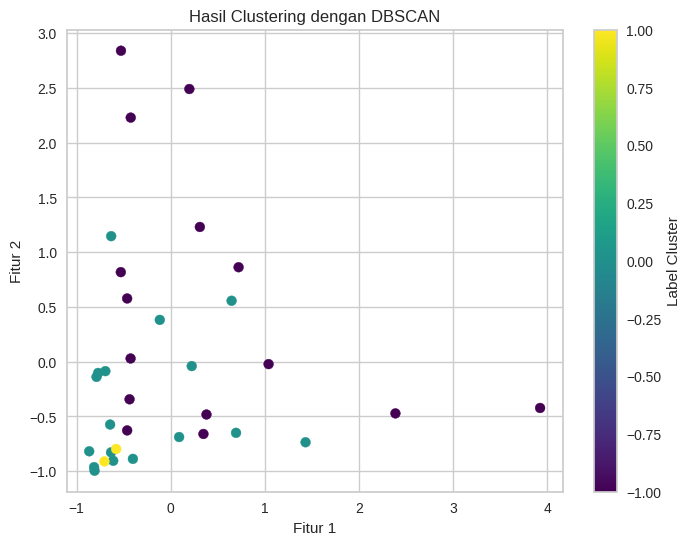

In [ ]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Gunakan nilai eps terbaik dari grafik kamu
dbscan = DBSCAN(eps=2.9, min_samples=2)  # sesuaikan eps jika perlu
labels = dbscan.fit_predict(X_scaled)

# Visualisasi hasil clustering
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=50)
plt.title('Hasil Clustering dengan DBSCAN')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.colorbar(label='Label Cluster')
plt.grid(True)
plt.show()

In [ ]:
df_dbscan['cluster_dbscan'] = labels

In [ ]:
import numpy as np

print("Label unik DBSCAN:", np.unique(labels))

Label unik DBSCAN: [-1  0  1]


In [ ]:
import pandas as pd

pd.Series(labels).value_counts().sort_index()

,count
-1,15
0,17
1,2


In [ ]:
df_dbscan

,Provinsi,Fakor Perceraian - Zina,Fakor Perceraian - Mabuk,Fakor Perceraian - Madat,Fakor Perceraian - Judi,Fakor Perceraian - Meninggalkan Salah satu Pihak,Fakor Perceraian - Dihukum Penjara,Fakor Perceraian - Poligami,Fakor Perceraian - Kekerasan Dalam Rumah Tangga,Fakor Perceraian - Cacat Badan,Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus,Fakor Perceraian - Kawin Paksa,Fakor Perceraian - Murtad,Fakor Perceraian - Ekonomi,Fakor Perceraian - Jumlah,cluster_dbscan
0,Aceh,6.0,10.0,18.0,26.0,551.0,61.0,28.0,122.0,16.0,5035.0,3.0,9.0,218.0,6103.0,0
1,Sumatera Utara,4.0,8.0,23.0,58.0,830.0,62.0,23.0,117.0,4.0,14454.0,15.0,73.0,299.0,15955.0,0
2,Sumatera Barat,2.0,7.0,5.0,30.0,936.0,29.0,22.0,100.0,6.0,6922.0,8.0,9.0,224.0,8292.0,0
3,Riau,5.0,12.0,25.0,36.0,745.0,99.0,12.0,125.0,7.0,6922.0,5.0,18.0,231.0,8242.0,0
4,Jambi,4.0,20.0,30.0,46.0,375.0,34.0,9.0,77.0,1.0,3746.0,2.0,6.0,230.0,4580.0,-1
5,Sumatera Selatan,19.0,38.0,35.0,120.0,769.0,83.0,35.0,427.0,7.0,7851.0,10.0,18.0,778.0,10180.0,0
6,Bengkulu,2.0,8.0,4.0,26.0,263.0,18.0,6.0,85.0,1.0,2991.0,3.0,5.0,130.0,3539.0,0
7,Lampung,8.0,72.0,9.0,131.0,655.0,31.0,29.0,259.0,6.0,11195.0,14.0,40.0,2168.0,14603.0,0
8,Kepulauan Bangka Belitung,2.0,39.0,5.0,65.0,163.0,18.0,3.0,123.0,3.0,1601.0,2.0,6.0,268.0,2291.0,-1
9,Kepulauan Riau,10.0,14.0,6.0,22.0,311.0,23.0,3.0,93.0,2.0,2749.0,3.0,4.0,148.0,3385.0,0


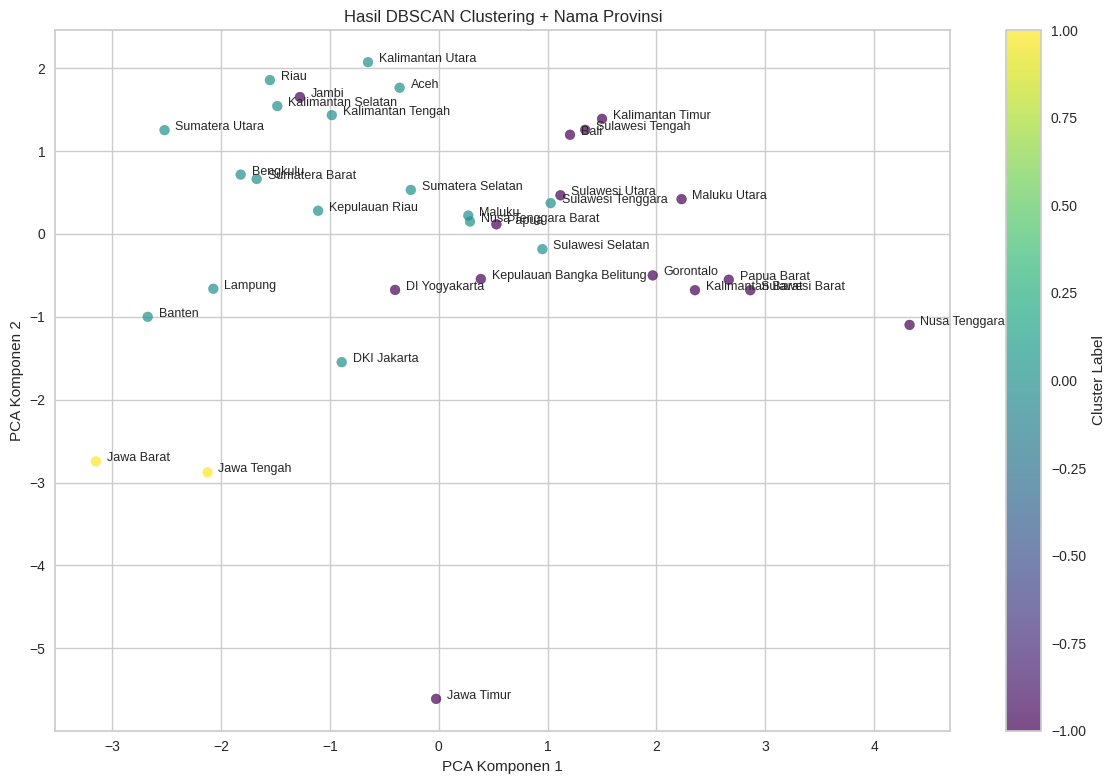

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Misal hasil DBSCAN:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=2.9, min_samples=2)  # gunakan eps terbaik hasil evaluasi
labels = dbscan.fit_predict(X_scaled)

# PCA untuk 2D visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)

# Tambahkan nama provinsi
df = clean_df.reset_index(drop=True)
for i in range(len(X_pca)):
    prov = df.iloc[i]['Provinsi']
    plt.text(X_pca[i, 0]+0.1, X_pca[i, 1], prov, fontsize=9)

# Title dan axis
plt.title('Hasil DBSCAN Clustering + Nama Provinsi')
plt.xlabel('PCA Komponen 1')
plt.ylabel('PCA Komponen 2')
plt.grid(True)
plt.colorbar(scatter, label='Cluster Label')
plt.tight_layout()
plt.show()

# Evaluasi hasil

🔍 Mengapa Banyak Contoh Pakai Rasio?
Tujuannya biar adil antar-provinsi. Misalnya:

Jakarta punya 10.000 kasus, 5.000 karena ekonomi → 50%

Kalbar punya 100 kasus, 50 karena ekonomi → 50%

Kalau clustering pakai jumlah absolut, Jakarta dan Kalbar bisa masuk klaster berbeda hanya karena jumlah populasinya, bukan pola penyebab.

Alasan gunakan rasio jika:

Kamu ingin kelompokkan provinsi berdasarkan pola penyebab perceraian, bukan kuantitas.

## KMeans

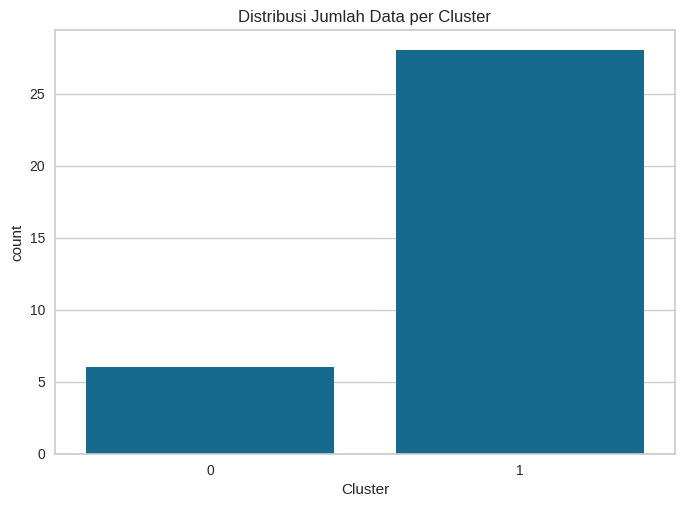

In [ ]:
sns.countplot(x='Cluster', data=df_kmeans)
plt.title('Distribusi Jumlah Data per Cluster')
plt.show()

<Axes: xlabel='Cluster', ylabel='count'>

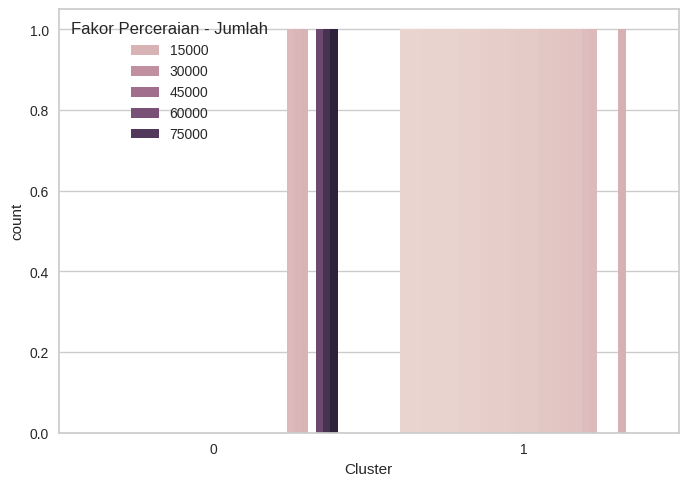

In [ ]:
df_kmeans.groupby('Cluster')['Fakor Perceraian - Jumlah'].value_counts(normalize=True)
sns.countplot(x='Cluster', hue='Fakor Perceraian - Jumlah', data=df_kmeans)

<Axes: xlabel='Cluster', ylabel='count'>

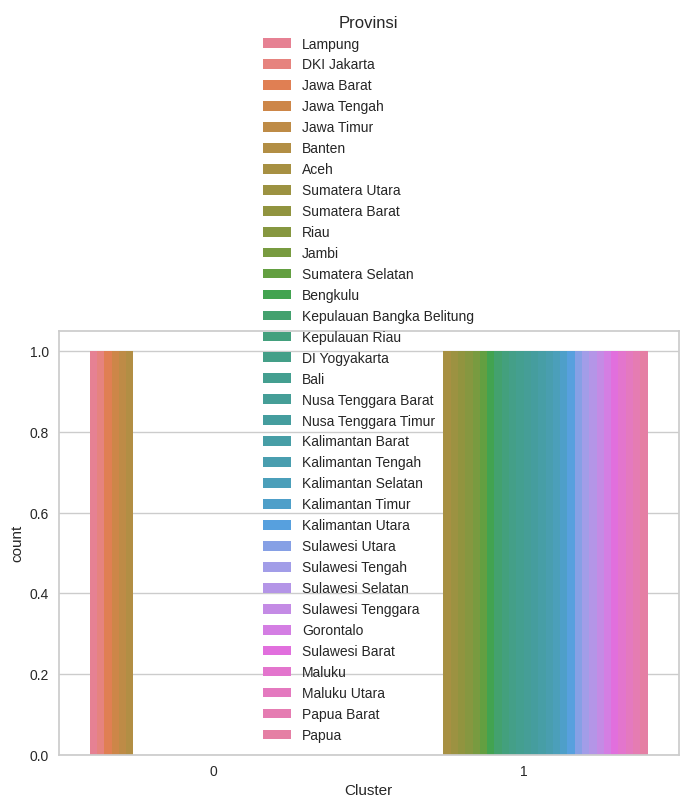

In [ ]:
df_kmeans.groupby('Cluster')['Provinsi'].value_counts(normalize=True)
sns.countplot(x='Cluster', hue='Provinsi', data=df_kmeans)

In [ ]:
df_kmeans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, 0 to 34
Data columns (total 16 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Provinsi                                                        34 non-null     object 
 1   Fakor Perceraian - Zina                                         34 non-null     float64
 2   Fakor Perceraian - Mabuk                                        34 non-null     float64
 3   Fakor Perceraian - Madat                                        34 non-null     float64
 4   Fakor Perceraian - Judi                                         34 non-null     float64
 5   Fakor Perceraian - Meninggalkan Salah satu Pihak                34 non-null     float64
 6   Fakor Perceraian - Dihukum Penjara                              34 non-null     float64
 7   Fakor Perceraian - Poligami                                 

In [ ]:
df_kmeans.groupby('Cluster')['Provinsi'].value_counts()

Cluster  Provinsi                 
0        Banten                       1
         DKI Jakarta                  1
         Jawa Barat                   1
         Jawa Tengah                  1
         Jawa Timur                   1
         Lampung                      1
1        Aceh                         1
         Bali                         1
         Bengkulu                     1
         DI Yogyakarta                1
         Gorontalo                    1
         Jambi                        1
         Kalimantan Barat             1
         Kalimantan Selatan           1
         Kalimantan Tengah            1
         Kalimantan Timur             1
         Kalimantan Utara             1
         Kepulauan Bangka Belitung    1
         Kepulauan Riau               1
         Maluku                       1
         Maluku Utara                 1
         Nusa Tenggara Barat          1
         Nusa Tenggara Timur          1
         Papua                        1
         Papua Barat                  1
         Riau                         1
         Sulawesi Barat               1
         Sulawesi Selatan             1
         Sulawesi Tengah              1
         Sulawesi Tenggara            1
         Sulawesi Utara               1
         Sumatera Barat               1
         Sumatera Selatan             1
         Sumatera Utara               1
Name: count, dtype: int64

In [ ]:
faktor_cols = [col for col in df_kmeans.columns
               if col.startswith('Fakor') and col != 'Fakor Perceraian - Jumlah']

cluster_avg_faktor = df_kmeans.groupby('Cluster')[faktor_cols].mean()
cluster_avg_faktor

,Fakor Perceraian - Zina,Fakor Perceraian - Mabuk,Fakor Perceraian - Madat,Fakor Perceraian - Judi,Fakor Perceraian - Meninggalkan Salah satu Pihak,Fakor Perceraian - Dihukum Penjara,Fakor Perceraian - Poligami,Fakor Perceraian - Kekerasan Dalam Rumah Tangga,Fakor Perceraian - Cacat Badan,Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus,Fakor Perceraian - Kawin Paksa,Fakor Perceraian - Murtad,Fakor Perceraian - Ekonomi
Cluster,,,,,,,,,,,,,
0,140.0,158.833333,27.166667,331.333333,2963.833333,87.333333,75.833333,632.500000,21.000000,25292.000000,42.5,95.000000,15755.333333
1,6.0,37.892857,10.892857,32.178571,481.500000,28.964286,14.321429,123.142857,4.714286,3549.035714,4.0,15.571429,202.357143


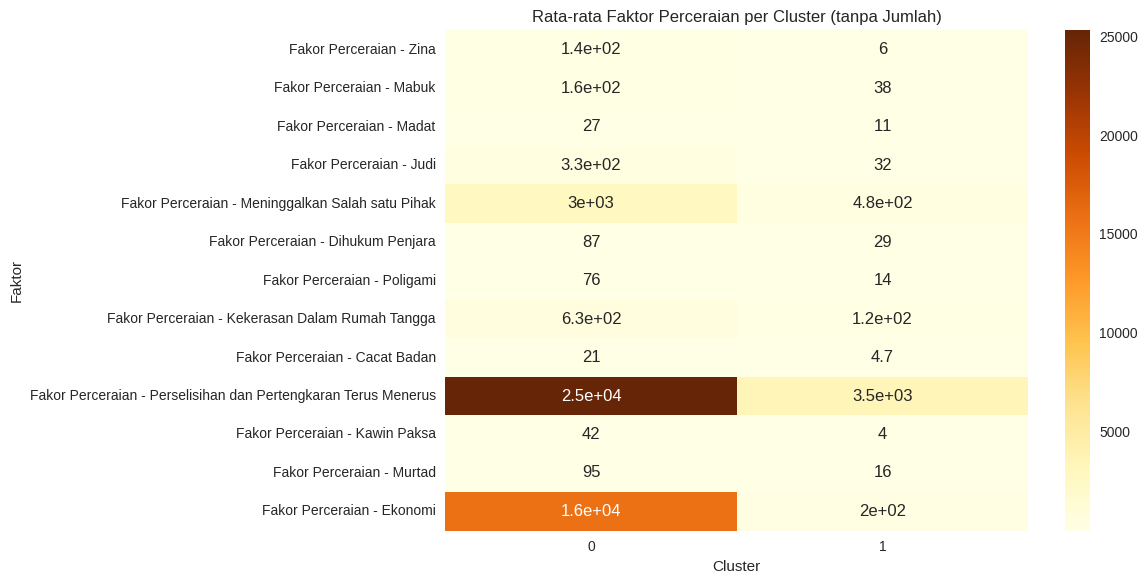

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_avg_faktor.T, annot=True, cmap='YlOrBr')
plt.title('Rata-rata Faktor Perceraian per Cluster (tanpa Jumlah)')
plt.xlabel('Cluster')
plt.ylabel('Faktor')
plt.tight_layout()
plt.show()

In [ ]:
dominant_factors = cluster_avg_faktor.idxmax(axis=1)
dominant_factors

,0
Cluster,
0,Fakor Perceraian - Perselisihan dan Pertengkar...
1,Fakor Perceraian - Perselisihan dan Pertengkar...


In [ ]:
df_kmeans.groupby('Cluster')['Provinsi'].value_counts()

Cluster  Provinsi                 
0        Banten                       1
         DKI Jakarta                  1
         Jawa Barat                   1
         Jawa Tengah                  1
         Jawa Timur                   1
         Lampung                      1
1        Aceh                         1
         Bali                         1
         Bengkulu                     1
         DI Yogyakarta                1
         Gorontalo                    1
         Jambi                        1
         Kalimantan Barat             1
         Kalimantan Selatan           1
         Kalimantan Tengah            1
         Kalimantan Timur             1
         Kalimantan Utara             1
         Kepulauan Bangka Belitung    1
         Kepulauan Riau               1
         Maluku                       1
         Maluku Utara                 1
         Nusa Tenggara Barat          1
         Nusa Tenggara Timur          1
         Papua                        1
         Papua Barat                  1
         Riau                         1
         Sulawesi Barat               1
         Sulawesi Selatan             1
         Sulawesi Tengah              1
         Sulawesi Tenggara            1
         Sulawesi Utara               1
         Sumatera Barat               1
         Sumatera Selatan             1
         Sumatera Utara               1
Name: count, dtype: int64

In [ ]:
# Untuk melihat faktor kedua dominan
second_dominant = cluster_avg_faktor.apply(lambda row: row.sort_values(ascending=False).index[1], axis=1)
second_dominant

,0
Cluster,
0,Fakor Perceraian - Ekonomi
1,Fakor Perceraian - Meninggalkan Salah satu Pihak


In [ ]:
top5_factors_per_cluster = cluster_avg_faktor.apply(lambda row: row.sort_values(ascending=False).head(5).index.tolist(), axis=1)
print(top5_factors_per_cluster)

Cluster
0    [Fakor Perceraian - Perselisihan dan Pertengka...
1    [Fakor Perceraian - Perselisihan dan Pertengka...
dtype: object


In [ ]:
top5_factors_with_values = cluster_avg_faktor.apply(lambda row: row.sort_values(ascending=False).head(5).to_dict(), axis=1)
top5_factors_with_values

,0
Cluster,
0,{'Fakor Perceraian - Perselisihan dan Pertengk...
1,{'Fakor Perceraian - Perselisihan dan Pertengk...


In [ ]:
for cluster, factors in top5_factors_with_values.items():
    print(f"\nCluster {cluster} - Top 5 Faktor:")
    for factor, value in factors.items():
        print(f"  {factor}: {value:.2f}")


Cluster 0 - Top 5 Faktor:
  Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus: 25292.00
  Fakor Perceraian - Ekonomi: 15755.33
  Fakor Perceraian - Meninggalkan Salah satu Pihak: 2963.83
  Fakor Perceraian - Kekerasan Dalam Rumah Tangga: 632.50
  Fakor Perceraian - Judi: 331.33

Cluster 1 - Top 5 Faktor:
  Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus: 3549.04
  Fakor Perceraian - Meninggalkan Salah satu Pihak: 481.50
  Fakor Perceraian - Ekonomi: 202.36
  Fakor Perceraian - Kekerasan Dalam Rumah Tangga: 123.14
  Fakor Perceraian - Mabuk: 37.89


In [ ]:
pd.DataFrame(df_kmeans).to_csv('cluster_cerai_kmeans.csv', index=False)

In [ ]:
pd.DataFrame(df_dbscan).to_csv('cluster_cerai_dbscan.csv', index=False)

## DBSCAN

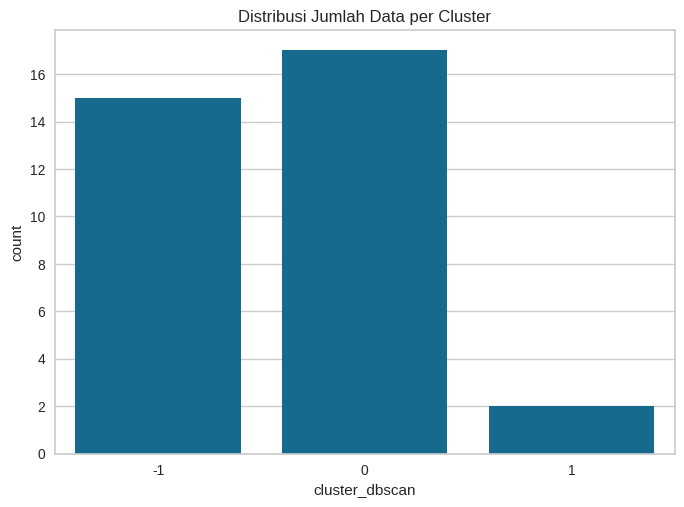

In [ ]:
sns.countplot(x='cluster_dbscan', data=df_dbscan)
plt.title('Distribusi Jumlah Data per Cluster')
plt.show()

<Axes: xlabel='cluster_dbscan', ylabel='count'>

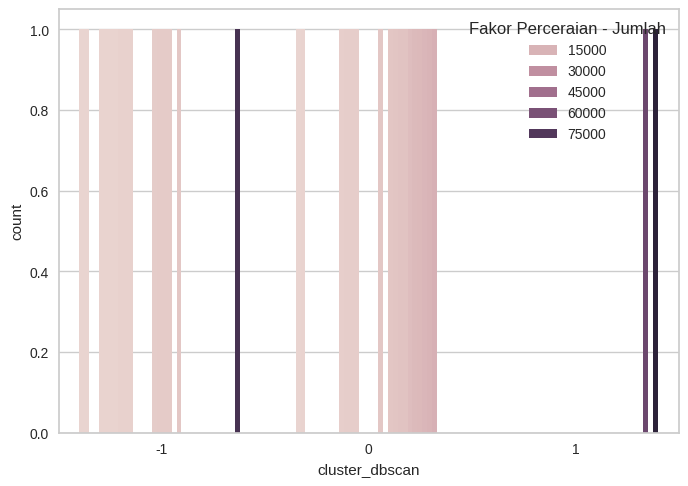

In [ ]:
df_dbscan.groupby('cluster_dbscan')['Fakor Perceraian - Jumlah'].value_counts(normalize=True)
sns.countplot(x='cluster_dbscan', hue='Fakor Perceraian - Jumlah', data=df_dbscan)

<Axes: xlabel='cluster_dbscan', ylabel='count'>

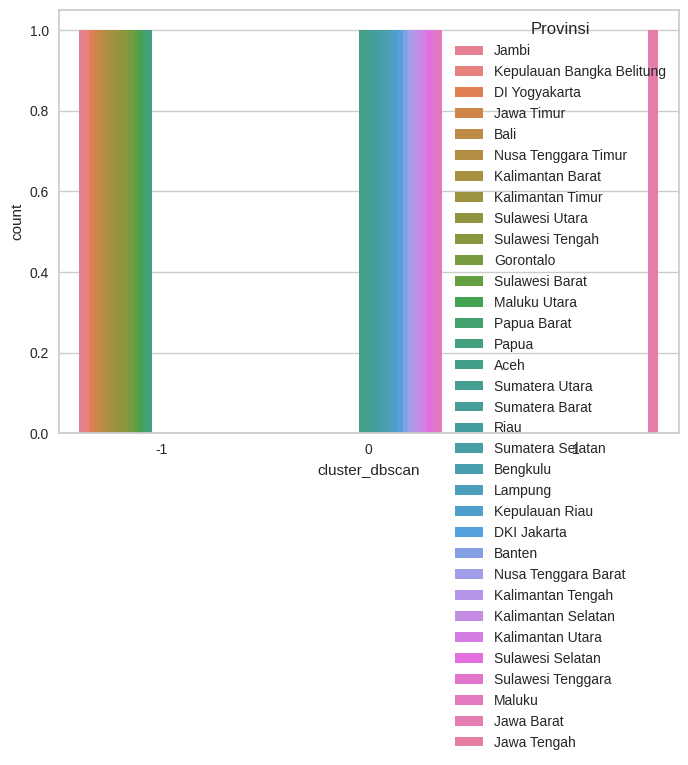

In [ ]:
df_dbscan.groupby('cluster_dbscan')['Provinsi'].value_counts(normalize=True)
sns.countplot(x='cluster_dbscan', hue='Provinsi', data=df_dbscan)

In [ ]:
df_dbscan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, 0 to 34
Data columns (total 16 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Provinsi                                                        34 non-null     object 
 1   Fakor Perceraian - Zina                                         34 non-null     float64
 2   Fakor Perceraian - Mabuk                                        34 non-null     float64
 3   Fakor Perceraian - Madat                                        34 non-null     float64
 4   Fakor Perceraian - Judi                                         34 non-null     float64
 5   Fakor Perceraian - Meninggalkan Salah satu Pihak                34 non-null     float64
 6   Fakor Perceraian - Dihukum Penjara                              34 non-null     float64
 7   Fakor Perceraian - Poligami                                 

In [ ]:
df_dbscan.groupby('cluster_dbscan')['Provinsi'].value_counts()

cluster_dbscan  Provinsi                 
-1              Bali                         1
                DI Yogyakarta                1
                Gorontalo                    1
                Jambi                        1
                Jawa Timur                   1
                Kalimantan Barat             1
                Kalimantan Timur             1
                Kepulauan Bangka Belitung    1
                Maluku Utara                 1
                Nusa Tenggara Timur          1
                Papua                        1
                Papua Barat                  1
                Sulawesi Barat               1
                Sulawesi Tengah              1
                Sulawesi Utara               1
 0              Aceh                         1
                Banten                       1
                Bengkulu                     1
                DKI Jakarta                  1
                Kalimantan Selatan           1
                Kalimantan Tengah            1
                Kalimantan Utara             1
                Kepulauan Riau               1
                Lampung                      1
                Maluku                       1
                Nusa Tenggara Barat          1
                Riau                         1
                Sulawesi Selatan             1
                Sulawesi Tenggara            1
                Sumatera Barat               1
                Sumatera Selatan             1
                Sumatera Utara               1
 1              Jawa Barat                   1
                Jawa Tengah                  1
Name: count, dtype: int64

In [ ]:
faktor_cols = [col for col in df_dbscan.columns
               if col.startswith('Fakor') and col != 'Fakor Perceraian - Jumlah']

cluster_avg_faktor = df_dbscan.groupby('cluster_dbscan')[faktor_cols].mean()
cluster_avg_faktor

,Fakor Perceraian - Zina,Fakor Perceraian - Mabuk,Fakor Perceraian - Madat,Fakor Perceraian - Judi,Fakor Perceraian - Meninggalkan Salah satu Pihak,Fakor Perceraian - Dihukum Penjara,Fakor Perceraian - Poligami,Fakor Perceraian - Kekerasan Dalam Rumah Tangga,Fakor Perceraian - Cacat Badan,Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus,Fakor Perceraian - Kawin Paksa,Fakor Perceraian - Murtad,Fakor Perceraian - Ekonomi
cluster_dbscan,,,,,,,,,,,,,
-1,51.266667,67.466667,14.600000,79.600000,683.066667,27.933333,21.733333,224.000000,5.733333,4158.600000,14.266667,21.866667,2353.000000
0,9.235294,41.764706,11.764706,55.411765,659.941176,37.470588,19.058824,170.235294,5.882353,6047.764706,5.647059,21.470588,576.882353
1,41.000000,146.000000,24.500000,376.500000,4900.000000,139.500000,103.000000,494.500000,36.000000,42967.000000,28.500000,156.500000,27548.000000


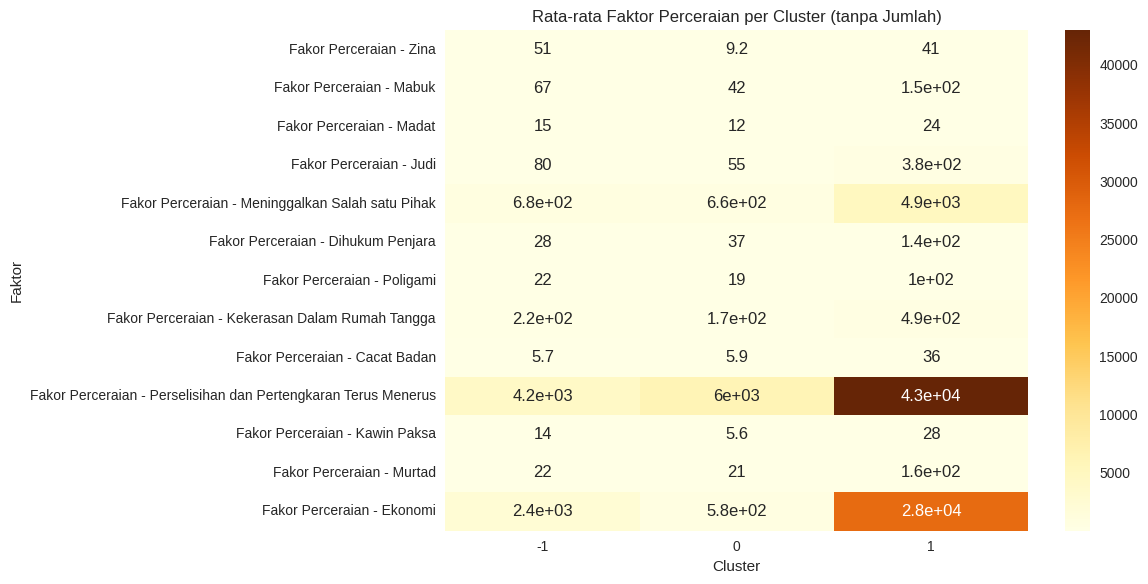

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_avg_faktor.T, annot=True, cmap='YlOrBr')
plt.title('Rata-rata Faktor Perceraian per Cluster (tanpa Jumlah)')
plt.xlabel('Cluster')
plt.ylabel('Faktor')
plt.tight_layout()
plt.show()

In [ ]:
dominant_factors = cluster_avg_faktor.idxmax(axis=1)
dominant_factors

,0
cluster_dbscan,
-1,Fakor Perceraian - Perselisihan dan Pertengkar...
0,Fakor Perceraian - Perselisihan dan Pertengkar...
1,Fakor Perceraian - Perselisihan dan Pertengkar...


In [ ]:
df_dbscan.groupby('cluster_dbscan')['Provinsi'].value_counts()

cluster_dbscan  Provinsi                 
-1              Bali                         1
                DI Yogyakarta                1
                Gorontalo                    1
                Jambi                        1
                Jawa Timur                   1
                Kalimantan Barat             1
                Kalimantan Timur             1
                Kepulauan Bangka Belitung    1
                Maluku Utara                 1
                Nusa Tenggara Timur          1
                Papua                        1
                Papua Barat                  1
                Sulawesi Barat               1
                Sulawesi Tengah              1
                Sulawesi Utara               1
 0              Aceh                         1
                Banten                       1
                Bengkulu                     1
                DKI Jakarta                  1
                Kalimantan Selatan           1
                Kalimantan Tengah            1
                Kalimantan Utara             1
                Kepulauan Riau               1
                Lampung                      1
                Maluku                       1
                Nusa Tenggara Barat          1
                Riau                         1
                Sulawesi Selatan             1
                Sulawesi Tenggara            1
                Sumatera Barat               1
                Sumatera Selatan             1
                Sumatera Utara               1
 1              Jawa Barat                   1
                Jawa Tengah                  1
Name: count, dtype: int64

In [ ]:
# Untuk melihat faktor kedua dominan
second_dominant = cluster_avg_faktor.apply(lambda row: row.sort_values(ascending=False).index[1], axis=1)
second_dominant

,0
cluster_dbscan,
-1,Fakor Perceraian - Ekonomi
0,Fakor Perceraian - Meninggalkan Salah satu Pihak
1,Fakor Perceraian - Ekonomi


In [ ]:
top5_factors_per_cluster = cluster_avg_faktor.apply(lambda row: row.sort_values(ascending=False).head(5).index.tolist(), axis=1)
print(top5_factors_per_cluster)

cluster_dbscan
-1    [Fakor Perceraian - Perselisihan dan Pertengka...
 0    [Fakor Perceraian - Perselisihan dan Pertengka...
 1    [Fakor Perceraian - Perselisihan dan Pertengka...
dtype: object


In [ ]:
top5_factors_with_values = cluster_avg_faktor.apply(lambda row: row.sort_values(ascending=False).head(5).to_dict(), axis=1)
top5_factors_with_values

,0
cluster_dbscan,
-1,{'Fakor Perceraian - Perselisihan dan Pertengk...
0,{'Fakor Perceraian - Perselisihan dan Pertengk...
1,{'Fakor Perceraian - Perselisihan dan Pertengk...


In [ ]:
for cluster, factors in top5_factors_with_values.items():
    print(f"\nCluster {cluster} - Top 5 Faktor:")
    for factor, value in factors.items():
        print(f"  {factor}: {value:.2f}")


Cluster -1 - Top 5 Faktor:
  Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus: 4158.60
  Fakor Perceraian - Ekonomi: 2353.00
  Fakor Perceraian - Meninggalkan Salah satu Pihak: 683.07
  Fakor Perceraian - Kekerasan Dalam Rumah Tangga: 224.00
  Fakor Perceraian - Judi: 79.60

Cluster 0 - Top 5 Faktor:
  Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus: 6047.76
  Fakor Perceraian - Meninggalkan Salah satu Pihak: 659.94
  Fakor Perceraian - Ekonomi: 576.88
  Fakor Perceraian - Kekerasan Dalam Rumah Tangga: 170.24
  Fakor Perceraian - Judi: 55.41

Cluster 1 - Top 5 Faktor:
  Fakor Perceraian - Perselisihan dan Pertengkaran Terus Menerus: 42967.00
  Fakor Perceraian - Ekonomi: 27548.00
  Fakor Perceraian - Meninggalkan Salah satu Pihak: 4900.00
  Fakor Perceraian - Kekerasan Dalam Rumah Tangga: 494.50
  Fakor Perceraian - Judi: 376.50


# Menyimpan hasil

In [ ]:
pd.DataFrame(df_kmeans).to_csv('cluster_cerai_kmeans.csv', index=False)

In [ ]:
pd.DataFrame(df_dbscan).to_csv('cluster_cerai_dbscan.csv', index=False)

*menambahkan visualisasi silhoutte coeff, melihat warna jumlah klaster. Dan tambah visualisasi diagram hierarki

## Cek & atasi outlier

In [ ]:
for col in faktor_cols:
    Q1 = df_fix[col].quantile(0.25)
    Q3 = df_fix[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Hapus baris outlier untuk kolom ini
    fix_df = df_fix[(df_fix[col] >= lower_bound) & (df_fix[col] <= upper_bound)]

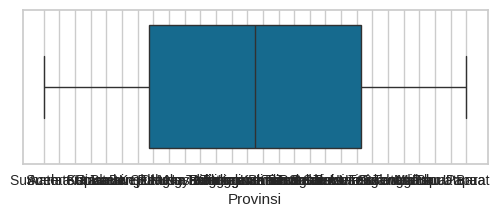

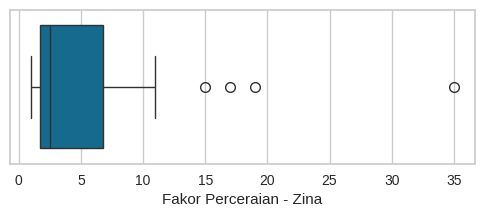

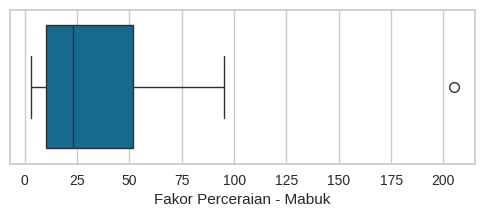

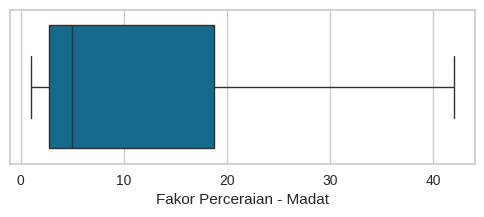

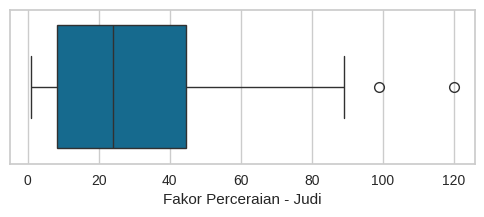

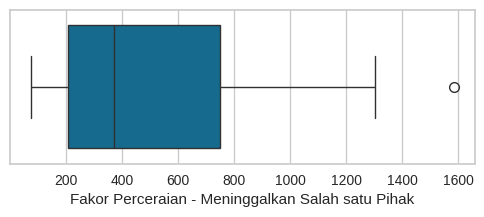

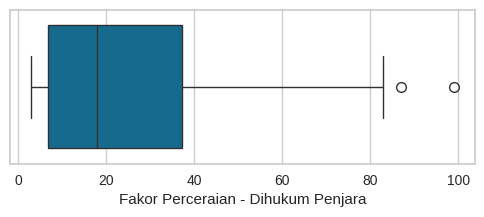

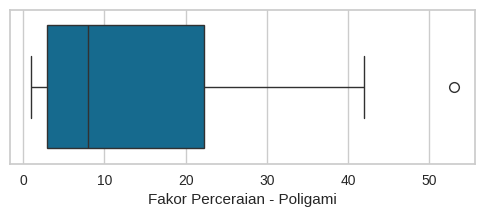

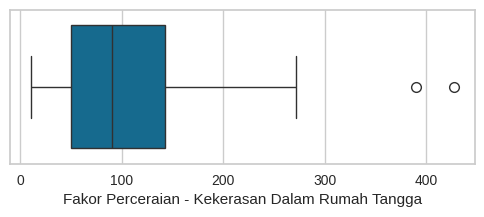

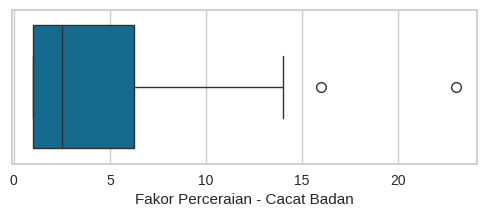

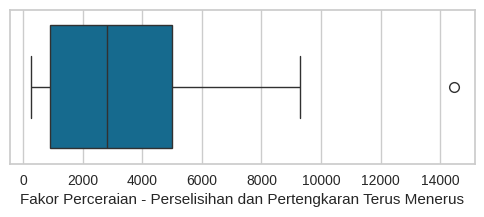

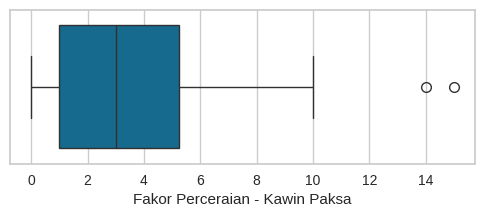

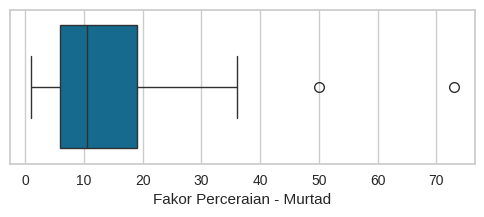

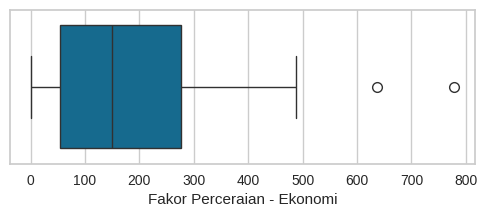

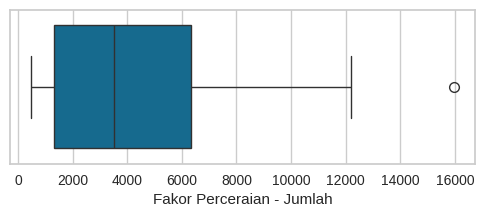

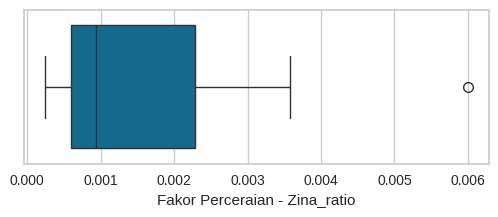

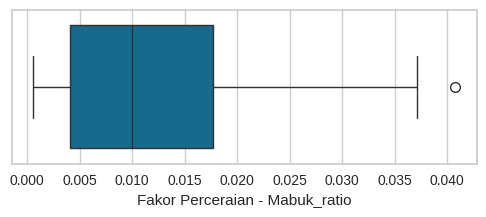

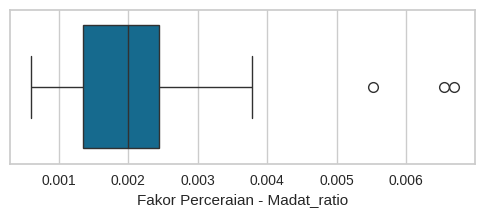

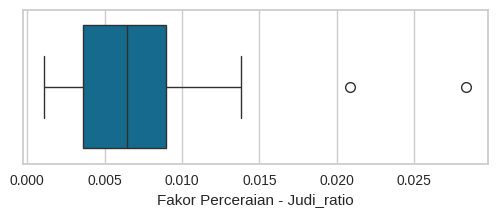

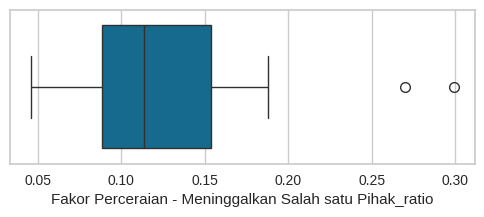

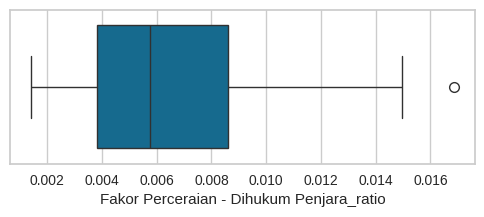

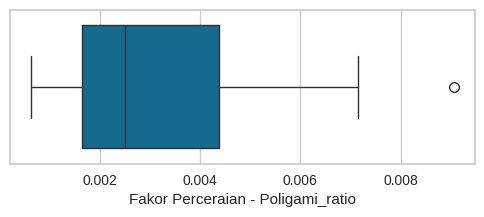

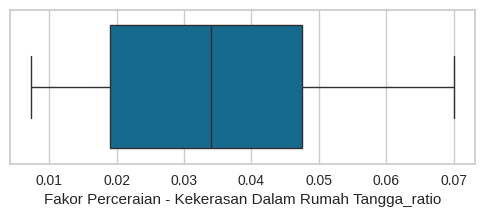

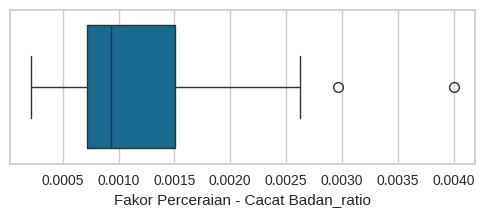

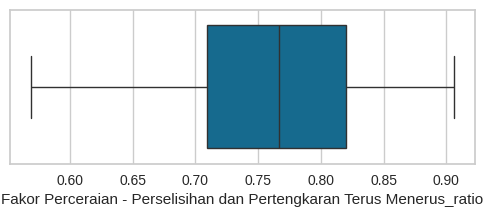

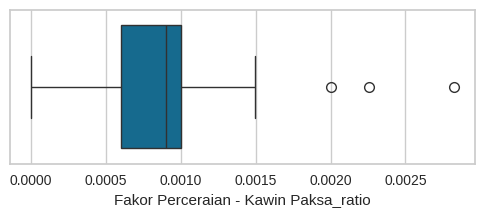

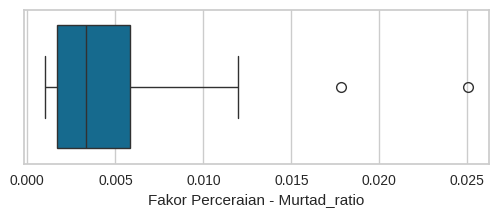

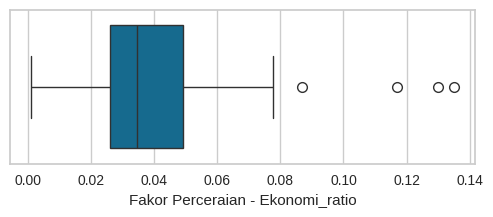

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in fix_df:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=col, data=fix_df)
    plt.xlabel(col)
    plt.show()